In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from numpy.random import seed
from keras.layers import Dense 
from keras.models import Model, Sequential, load_model
from keras.layers import Input, Dropout, Dense, LSTM, TimeDistributed, RepeatVector
from keras.models import Model
from keras.models import model_from_json
from keras import regularizers
from joblib import dump, load
import tensorflow as tf
from tensorflow.keras.models import load_model
from keras.callbacks import EarlyStopping
from birdsong import CanaryView
from birdsong.view import CanaryView
import arrow
import requests
matplotlib.rcParams['figure.figsize'] = [20, 8]
sns.set(style='darkgrid', palette='dark')

#ingnorar warnings
import warnings
warnings.filterwarnings('ignore')

# Establecer la semilla para TensorFlow y NumPy
tf.random.set_seed(10)
np.random.seed(10)

#Mostar todas las columnas en el dataframe
pd.set_option('display.max_columns', None)

### CONEXION CON HISTORIADOR CANARY

In [2]:
# Crear una instancia de CanaryView conectada a 192.168.10.211 con los puertos por defecto
canary_view = CanaryView(httpPort='55235', httpsPort='55236',  host='192.168.10.211')

In [3]:
# URL base del servidor y endpoint de la API
base_url = 'http://192.168.10.211:55235/api'
endpoint = base_url + '/v2/GetTagData2'

In [4]:
# tags = ["PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.EstadoDesf Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.I_MotorDesf Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorDesfR Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorDesfS Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorDesfT Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorLA Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorLL Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.VT_MotorLL Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Picador de Caña.TT_ChumLA Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Picador de Caña.TT_ChumLL Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.UH.TT_MotorAceite Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.EstadoOP Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.I_Pic Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_LA Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_LL Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_PicR Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_PicS Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_PicT Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.VT_PicLL Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Picador de Caña.TT_ChumLL Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.UH.PT_MotorUH Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.UH.TensionUH Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.EstadoOPPic2 Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.I_Pic2 Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TensionPic2 Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TT_Pic2R Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TT_Pic2S Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TT_Pic2T Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.VT_Pic2LL Value Y", 
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Picador de Caña.TT_ChumPic2LA Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Picador de Caña.TT_ChumPic2LL Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.UH.TensionPic2Red Value Y",
#         "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.UH.TT_ReductorAceite Value Y"]

In [4]:
tags = ["PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_LL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.I_Pic Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_PicR Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_PicS Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_PicT Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.VT_PicLL Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.UH.TT_MotorUH Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.TT_LA Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.UH.TensionUH Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Picador de Caña.TT_ChumLL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Picador de Caña.TT_ChumPic2LA Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Picador de Caña.TT_ChumPic2LL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.I_Pic2 Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TT_Pic2R Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TT_Pic2S Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TT_Pic2T Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.TensionPic2 Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.VT_Pic2LL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.UH.TT_ReductorAceite Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.UH.TensionPic2Red Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.I_MotorDesf Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorDesfR Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorDesfS Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorDesfT Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorLA Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.TT_MotorLL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Picador de Caña.TT_ChumLA Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Picador de Caña.TT_ChumLL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.UH.TT_MotorAceite Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.VT_MotorLL Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Conductores.I_EC101 ValueY",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Conductores.ST_EC101 ValueY",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Conductores.I_MC101 ValueY",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Conductores.I_MC102 ValueY",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Conductores.I_EC102 ValueY",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Conductores.I_EC103 ValueY",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 1.Motor.EstadoOP Value Y",
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Picadora 2.Motor.EstadoOPPic2 Value Y", 
        "PEAAAUCOI211.Extraccion_data.Preparacion Caña.Desfibrador.Motor.EstadoDesf Value Y",
        "PEAAAUCOI211.Calc.Preparacion Caña.Conductores.EC101 - Apagado"]

columnas = ['P1/TT_LL', 
 'P1/I_Pic', 
 'P1/TT_PicR', 
 'P1/TT_PicS', 
 'P1/TT_PicT', 
 'P1/VT_PicLL', 
 'P1/TT_MotorUH', 
 'P1/TT_LA', 
 'P1/TensionUH', 
 'P1/TT_ChumLL', 
 'P2/TT_ChumPic2LA', 
 'P2/TT_ChumPic2LL', 
 'P2/I_Pic2', 
 'P2/TT_Pic2R', 
 'P2/TT_Pic2S', 
 'P2/TT_Pic2T', 
 'P2/TensionPic2', 
 'P2/VT_Pic2LL', 
 'P2/TT_ReductorAceite', 
 'P2/TensionPic2Red', 
 'Desf/I_MotorDesf', 
 'Desf/TT_MotorDesfR', 
 'Desf/TT_MotorDesfS', 
 'Desf/TT_MotorDesfT', 
 'Desf/TT_MotorLA', 
 'Desf/TT_MotorLL', 
 'Desf/TT_ChumLA', 
 'Desf/TT_ChumLL', 
 'Desf/TT_MotorAceite', 
 'Desf/VT_MotorLL',
 'Conductor/I_EC101', 
 'Conductor/ST_EC101', 
 'Conductor/I_MC101', 
 'Conductor/I_MC102', 
 'Conductor/I_EC102', 
 'Conductor/I_EC103', 
 'Picadora 1 - Apagada', 
 'Picadora 2 - Apagada', 
 'Desfibrador - Apagado',
 'Conductor - Apagado']

In [5]:
def extraer_procesar_guardar_datos(tags, start_time, end_time,columnas, nombre_archivo):
    """
    Extrae datos de un rango de tiempo desde Canary, los procesa y los guarda en un archivo CSV.

    Parámetros:
    - tags: Lista de etiquetas a extraer.
    - start_time: Fecha de inicio en formato compatible con Canary.
    - end_time: Fecha de finalización en formato compatible con Canary.
    - columnas: Lista de nombres de columnas a renombrar en el DataFrame.
    - nombre_archivo: Ruta y nombre del archivo CSV de salida.

    Retorna:
    - df_final: DataFrame final con los datos procesados.
    """
    # Obtener datos del rango especificado
    data = canary_view.getTagData(
        tags=tags,
        startTime=start_time,
        endTime=end_time,
        aggregateName='TimeAverage',
        aggregateInterval='00:00:30'
    )

    # Procesar los datos directamente desde el generador
    datos = []
    for tag_path, values in data:  # Iteramos directamente sobre el generador
        for value in values:
            datos.append({
                'etiqueta': tag_path,
                'timestamp': value['timestamp'],
                'value': value['value']
            })

    # Convertir la lista de datos a un DataFrame
    df = pd.DataFrame(datos)

    # Pivoteo de los datos para organizar por etiquetas y timestamp
    df_pivot = df.pivot_table(index='timestamp', columns='etiqueta', values='value')
    df_pivot = df_pivot[tags]
    # Reemplazar valores nulos por 0
    df_pivot.fillna(0, inplace=True)

    # Renombrar las columnas
    df_pivot.columns = columnas

    # Guardar a un archivo CSV
    df_pivot.to_csv(nombre_archivo, index=True)

    # Leer nuevamente el CSV para ajustar el índice de tiempo y aplicar la zona horaria
    df_final = pd.read_csv(nombre_archivo, index_col=0)
    df_final.index = pd.to_datetime(df_final.index, format='ISO8601').tz_convert('America/Lima')
    
    return df_final

In [6]:
# #Periodo 2023
start_2023 = '2023-08-19T00:00:00Z'
end_2023 = '2023-12-17T00:00:00Z'

#Periodo Agosto 2024
start_08_2024 = '2024-07-31T00:00:00Z'
end_08_2024 = '2024-08-30T00:00:00Z'

#Periodo Septiembre 2024
start_09_2024 = '2024-08-30T00:00:00Z'
end_09_2024 = '2024-09-26T00:00:00Z'

#Periodo Septiembre 2024
start_10_2024 = '2024-09-30T00:00:00Z'
end_10_2024 = '2024-10-14T00:00:00Z'

df_2023 = extraer_procesar_guardar_datos(tags,start_2023,end_2023,columnas,'data/EC101/df_EC101_2023.csv')
print(df_2023.shape)
df_08_2024 = extraer_procesar_guardar_datos(tags,start_08_2024,end_08_2024,columnas,'data/EC101/df_EC101_08_2024.csv')
print(df_08_2024.shape)
df_09_2024 = extraer_procesar_guardar_datos(tags,start_09_2024,end_09_2024,columnas,'data/EC101/df_EC101_09_2024.csv')
print(df_09_2024.shape)
df_10_2024 = extraer_procesar_guardar_datos(tags,start_10_2024,end_10_2024,columnas,'data/EC101/df_EC101_10_2024.csv')
print(df_10_2024.shape)

df = pd.concat([df_2023,df_08_2024, df_09_2024, df_10_2024])
#Remover filas con las mismas fechas en el index
df = df[~df.index.duplicated(keep='first')]
df.to_csv('data/EC101/df_EC101.csv',index=True)
print(df.shape)

(345600, 40)
(86400, 40)
(77760, 40)
(40320, 40)
(550080, 40)


### FILTRAR LOS DATOS

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
P1/TT_LL,550080.0,50.278962,17.344125,0.000000,40.572915,58.715277,61.882716,70.996333
P1/I_Pic,550080.0,38.762676,21.695313,0.000000,46.280099,49.706264,51.811601,249.900000
P1/TT_PicR,550080.0,50.136409,16.056716,0.000000,49.295909,55.542051,59.863040,77.930167
P1/TT_PicS,550080.0,48.967666,15.848226,0.000000,48.344906,54.431905,58.542631,76.337768
P1/TT_PicT,550080.0,51.216309,16.902167,0.000000,51.000000,57.158563,61.462190,79.698109
P1/VT_PicLL,550080.0,2.158610,1.386716,0.000000,1.353182,2.358813,3.078910,10.775990
P1/TT_MotorUH,550080.0,30.997160,9.112390,0.000000,27.113353,32.634066,36.412278,53.773268
P1/TT_LA,550080.0,39.829874,12.032222,0.000000,37.550153,42.512538,46.986884,68.342980
P1/TensionUH,550080.0,1.718727,0.923366,0.000000,2.000000,2.203500,2.252000,2.729000
P1/TT_ChumLL,550080.0,43.251712,21.253680,-3.703704,40.888310,49.199459,56.855708,84.498454


In [8]:
# def moving_average(data_set, periods=3):
#     weights = np.ones(periods) / periods
#     return np.convolve(data_set, weights, mode='valid')
def moving_average_filter(data, columns, window_size):
    filtered_data = data.copy()
    for column in columns:
        filtered_data[column] = data[column].rolling(window=window_size,min_periods=1).mean()
    return filtered_data

In [9]:
def set_uncertainty(data, uncertainty_duration, columns):
    now = pd.Timestamp.now(tz='America/Lima')
    uncertainty_threshold = now - uncertainty_duration
    for column in columns:
        if column in data.columns:
            data[column] = data[column].where(data.index <= uncertainty_threshold, other=pd.NA)
    return data

In [10]:
columns_to_filter = ['P1/TT_LL', 
 'P1/I_Pic',
 'P1/TT_PicR', 
 'P1/TT_PicS', 
 'P1/TT_PicT', 
 'P1/VT_PicLL', 
 'P1/TT_MotorUH', 
 'P1/TT_LA', 
 'P1/TensionUH', 
 'P1/TT_ChumLL', 
 'P2/TT_ChumPic2LA', 
 'P2/TT_ChumPic2LL', 
 'P2/TT_Pic2R', 
 'P2/TT_Pic2S', 
 'P2/TT_Pic2T', 
 'P2/TensionPic2', 
 'P2/VT_Pic2LL', 
 'P2/TT_ReductorAceite', 
 'P2/TensionPic2Red', 
 'Desf/TT_MotorDesfR', 
 'Desf/TT_MotorDesfS', 
 'Desf/TT_MotorDesfT', 
 'Desf/TT_MotorLA', 
 'Desf/TT_MotorLL', 
 'Desf/TT_ChumLA', 
 'Desf/TT_ChumLL', 
 'Desf/TT_MotorAceite', 
 'Desf/VT_MotorLL',
 'Conductor/I_EC101', 
 'Conductor/ST_EC101', 
 'Conductor/I_MC101', 
 'Conductor/I_MC102', 
 'Conductor/I_EC102', 
 'Conductor/I_EC103']

df_filt = moving_average_filter(df,columns_to_filter,'50s')
df_filt['P1/I_Pic'] = df_filt['P1/I_Pic'].rolling('80s',closed='both').max()
df_filt['P2/I_Pic2'] = df_filt['P2/I_Pic2'].rolling('80s',closed='both').max()
df_filt['Desf/I_MotorDesf'] = df_filt['Desf/I_MotorDesf'].rolling('80s',closed='both').max()

df_filt['Conductor - Apagado'] = df_filt['Conductor - Apagado'].rolling('5min',center=True).max()
df_filt['Conductor - Apagado'] = df_filt['Conductor - Apagado'].rolling('5min',center=True).max()

# for item in df.columns:
#     plt.figure(figsize=(20, 4))
#     # Graficar la data original
#     plt.plot(df[item], label=f'{item} - Original', linestyle='-', color='blue')
#     # Graficar la data filtrada
#     plt.plot(df_filt[item], label=f'{item} - Filtrada', linestyle='--', color='orange')
    
#     plt.title(item)
#     plt.legend()
#     plt.show()

In [11]:
# Filtro para señales de encendido y apagado 
# Convertir a escalonada la señal y establecer una interpolación maxima
df_filt['Picadora 1 - Apagada'] = df_filt['Picadora 1 - Apagada'].ffill(limit=720)
df_filt.loc[df_filt.index.to_series().diff() > pd.Timedelta('30D'),'Picadora 1 - Apagada'] = np.nan

# Identificar periodos donde la señal es 0 y expandir 5 minutos
condition = (df_filt['Picadora 1 - Apagada'] == 0)
df_filt['Picadora 1 - Apagada'] = condition.rolling('5T',min_periods=1,center=True).max()

# Combinar periodos separados por menos de 15 minutos
df_filt['Picadora 1 - Apagada'] = df_filt['Picadora 1 - Apagada'].rolling('15T',min_periods=1).max()

# Expandir 5 minutos hacia adelante
df_filt['Picadora 1 - Apagada'] = df_filt['Picadora 1 - Apagada'].shift(-5,freq='T').fillna(False)


In [12]:
# Identificar periodos donde la señal es 0 y expandir 5 minutos
condition = (df_filt['Picadora 2 - Apagada'] == 0)
df_filt['Picadora 2 - Apagada'] = condition.rolling('5T',min_periods=1,center=True).max()

# Combinar periodos separados por menos de 15 minutos
df_filt['Picadora 2 - Apagada'] = df_filt['Picadora 2 - Apagada'].rolling('15T',min_periods=1).max()

# Expandir 5 minutos hacia adelante
df_filt['Picadora 2 - Apagada'] = df_filt['Picadora 2 - Apagada'].shift(-5,freq='T').fillna(False)

In [13]:
# Identificar periodos donde la señal es 0 y expandir 5 minutos
condition = (df_filt['Desfibrador - Apagado'] == 0)
df_filt['Desfibrador - Apagado'] = condition.rolling('5T',min_periods=1,center=True).max()

# Combinar periodos separados por menos de 15 minutos
df_filt['Desfibrador - Apagado'] = df_filt['Desfibrador - Apagado'].rolling('15T',min_periods=1).max()

# Expandir 5 minutos hacia adelante
df_filt['Desfibrador - Apagado'] = df_filt['Desfibrador - Apagado'].shift(-5,freq='T').fillna(False)

In [14]:
df_filt

,P1/TT_LL,P1/I_Pic,P1/TT_PicR,P1/TT_PicS,P1/TT_PicT,P1/VT_PicLL,P1/TT_MotorUH,P1/TT_LA,P1/TensionUH,P1/TT_ChumLL,P2/TT_ChumPic2LA,P2/TT_ChumPic2LL,P2/I_Pic2,P2/TT_Pic2R,P2/TT_Pic2S,P2/TT_Pic2T,P2/TensionPic2,P2/VT_Pic2LL,P2/TT_ReductorAceite,P2/TensionPic2Red,Desf/I_MotorDesf,Desf/TT_MotorDesfR,Desf/TT_MotorDesfS,Desf/TT_MotorDesfT,Desf/TT_MotorLA,Desf/TT_MotorLL,Desf/TT_ChumLA,Desf/TT_ChumLL,Desf/TT_MotorAceite,Desf/VT_MotorLL,Conductor/I_EC101,Conductor/ST_EC101,Conductor/I_MC101,Conductor/I_MC102,Conductor/I_EC102,Conductor/I_EC103,Picadora 1 - Apagada,Picadora 2 - Apagada,Desfibrador - Apagado,Conductor - Apagado
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-08-18 19:00:00-05:00,61.049380,49.400547,57.850115,56.651233,59.055749,1.774873,33.146942,49.131943,2.10650,50.252700,62.712189,44.667245,421.899994,75.868057,77.181712,75.416664,424.083333,0.713745,39.019459,1.9600,140.252983,61.069635,63.289929,62.586804,44.491705,43.983409,57.308061,63.153934,31.231674,2.619566,47.815194,1050.000000,161.293642,30.773889,31.133811,13.681706,0.0,0.0,0.0,0.0
2023-08-18 19:00:30-05:00,61.049380,49.400547,57.850115,56.651233,59.055749,1.774873,33.146942,49.131943,2.10650,50.252700,62.712189,44.667245,421.899994,75.868057,77.181712,75.416664,424.083333,0.713745,39.019459,1.9600,140.252983,61.069635,63.289929,62.586804,44.491705,43.983409,57.308061,63.153934,31.231674,2.619566,47.815194,1050.000000,161.293642,30.773889,31.133811,13.681706,0.0,0.0,0.0,0.0
2023-08-18 19:01:00-05:00,61.046487,49.631336,57.838541,56.649304,59.048997,1.719642,33.153030,49.130978,2.10600,50.237750,62.694828,44.662904,433.666667,75.854070,77.154222,75.397375,429.783333,0.713846,39.003906,1.9555,149.043070,61.101947,63.330921,62.611881,44.490258,43.977140,57.290700,63.145736,31.223897,2.642628,48.188950,1050.000000,160.681443,30.518778,31.224731,13.666190,0.0,0.0,0.0,0.0
2023-08-18 19:01:30-05:00,61.043593,49.862126,57.826967,56.647374,59.042246,1.664411,33.159119,49.130014,2.10550,50.222800,62.677467,44.658564,433.666667,75.840084,77.126733,75.378085,435.483333,0.713947,38.988354,1.9510,149.043070,61.134258,63.371912,62.636958,44.488811,43.970870,57.273339,63.137538,31.216121,2.665690,48.562705,1050.000000,160.069244,30.263667,31.315651,13.650675,0.0,0.0,0.0,0.0
2023-08-18 19:02:00-05:00,61.049863,49.862126,57.825038,56.643999,59.039834,1.727509,33.154960,49.126156,2.11025,50.219907,62.656248,44.651812,433.666667,75.832849,77.113712,75.366511,429.108333,0.717077,38.999807,1.9630,149.043070,61.185377,63.419656,62.706403,44.473379,43.958814,57.252120,63.130786,31.207199,2.639485,48.084398,1049.500000,159.283419,30.370000,31.223716,13.734067,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-13 18:57:30-05:00,29.386092,0.000000,30.752797,29.843749,29.106867,0.161135,23.634620,27.987557,0.00000,-3.700810,65.485625,42.252121,395.000000,80.728682,82.362076,81.100498,395.000000,1.734841,37.822746,2.1300,59.783465,50.052565,51.575520,51.264467,51.951195,39.417919,47.470581,55.266201,32.956875,1.610147,1.943101,22.476185,0.008076,0.000611,0.006810,0.002143,NaN,NaN,NaN,1.0
2024-10-13 18:58:00-05:00,29.386092,0.000000,30.706018,29.859181,29.158468,0.163412,23.641010,27.952353,0.00000,-3.698881,65.482731,42.239583,395.000000,80.705052,82.332175,81.081208,395.000000,1.801544,37.759873,2.1300,59.783465,49.993730,51.497877,51.209008,51.947820,39.388021,47.456595,55.267166,32.944939,1.615792,0.006638,0.000000,0.007646,0.000444,0.006989,0.002183,NaN,NaN,NaN,1.0
2024-10-13 18:58:30-05:00,29.364390,0.000000,30.659722,29.857735,29.106867,0.145809,23.654996,27.933545,0.00000,-3.698881,65.465853,42.205825,395.000000,80.694443,82.289253,81.057578,395.000000,1.727782,37.687837,2.1300,59.783465,49.913676,51.403838,51.152584,51.944444,39.362944,47.453701,55.267166,32.921428,1.472109,0.006875,0.000000,0.008076,0.000833,0.006930,0.002063,NaN,NaN,N

In [16]:
# plt.figure(figsize=(20, 4))
# # Graficar la data original
# plt.plot(df['Picadora 1 - Apagada'], label=f'{item} - Original', linestyle='-', color='blue')
# # Graficar la data filtrada
# plt.plot(df_filt['Picadora 1 - Apagada'], label=f'{item} - Filtrada', linestyle='--', color='orange')

# plt.title('Picadora 1 - Apagada')
# plt.legend()
# plt.show()

In [17]:
# plt.figure(figsize=(20, 4))
# # Graficar la data original
# #plt.plot(df['Picadora 2 - Apagada'], label=f'{item} - Original', linestyle='-', color='blue')
# # Graficar la data filtrada
# plt.plot(df_filt['Picadora 2 - Apagada'], label=f'{item} - Filtrada', linestyle='--', color='orange')

# plt.title('Picadora 2 - Apagada')
# plt.legend()
# plt.show()

In [18]:
# plt.figure(figsize=(20, 4))
# # Graficar la data original
# plt.plot(df['Desfibrador - Apagado'], label=f'{item} - Original', linestyle='-', color='blue')
# # Graficar la data filtrada
# plt.plot(df_filt['Desfibrador - Apagado'], label=f'{item} - Filtrada', linestyle='--', color='orange')

# plt.title('Desfibrador - Apagado')
# plt.legend()
# plt.show()

In [15]:
df_filt.to_csv('data/EC101/df_EC101.csv',index=True)

In [16]:
df = pd.read_csv('data/EC101/df_EC101.csv',index_col=0)
df.index = pd.to_datetime(df.index).tz_convert('America/Lima')
#Remover filas donde 'Conductor - Apagado' es 1
df = df[df['Conductor - Apagado'] == 0]
print(df.shape)


(431951, 40)


In [17]:
df.tail()

,P1/TT_LL,P1/I_Pic,P1/TT_PicR,P1/TT_PicS,P1/TT_PicT,P1/VT_PicLL,P1/TT_MotorUH,P1/TT_LA,P1/TensionUH,P1/TT_ChumLL,P2/TT_ChumPic2LA,P2/TT_ChumPic2LL,P2/I_Pic2,P2/TT_Pic2R,P2/TT_Pic2S,P2/TT_Pic2T,P2/TensionPic2,P2/VT_Pic2LL,P2/TT_ReductorAceite,P2/TensionPic2Red,Desf/I_MotorDesf,Desf/TT_MotorDesfR,Desf/TT_MotorDesfS,Desf/TT_MotorDesfT,Desf/TT_MotorLA,Desf/TT_MotorLL,Desf/TT_ChumLA,Desf/TT_ChumLL,Desf/TT_MotorAceite,Desf/VT_MotorLL,Conductor/I_EC101,Conductor/ST_EC101,Conductor/I_MC101,Conductor/I_MC102,Conductor/I_EC102,Conductor/I_EC103,Picadora 1 - Apagada,Picadora 2 - Apagada,Desfibrador - Apagado,Conductor - Apagado
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-10-13 17:51:30-05:00,31.016589,0.0,32.520254,31.330053,29.156057,0.210764,26.658227,30.679011,0.0,-3.702739,68.097994,45.287421,450.100000,84.032601,85.913388,84.437691,445.883333,1.268929,42.095871,2.0985,158.422256,62.692899,64.647955,64.744404,54.384645,42.812500,49.188851,55.869019,34.918257,1.850211,52.465977,1152.041337,142.110481,33.499667,30.848925,15.661270,1.0,0.0,0.0,0.0
2024-10-13 17:52:00-05:00,31.014660,0.0,32.502893,31.314621,29.163773,0.212425,26.645809,30.670331,0.0,-3.702739,68.103781,45.258485,454.133333,84.030672,85.914352,84.434798,452.575000,1.263781,42.030044,2.0955,159.840266,62.729551,64.592978,64.782019,54.383680,42.799962,49.188851,55.856480,34.914399,1.869636,52.825270,1152.467399,139.972681,32.765667,31.107168,15.913214,1.0,0.0,0.0,0.0
2024-10-13 17:52:30-05:00,31.000675,0.0,32.482639,31.308834,29.160879,0.203673,26.610966,30.643325,0.0,-3.703704,68.098959,45.268130,454.133333,84.032601,85.893133,84.428047,440.750000,1.257343,41.983928,2.0925,159.840266,62.750771,64.677854,64.811918,54.380305,42.791281,49.161844,55.878665,34.915002,1.836214,53.138393,1152.015153,138.768901,33.150333,31.366368,15.865635,1.0,0.0,0.0,0.0
2024-10-13 17:53:00-05:00,30.991512,0.0,32.457562,31.299189,29.164737,0.206316,26.589385,30.618249,0.0,-3.702739,68.091725,45.267166,454.133333,84.022956,85.884935,84.426118,435.433333,1.259292,41.948362,2.0870,159.840266,62.779707,64.768517,64.834101,54.370660,42.784530,49.142553,55.889757,34.918679,1.838382,53.270209,1152.004328,150.801804,33.276000,31.799044,16.146786,1.0,0.0,0.0,0.0
2024-10-13 17:53:30-05:00,30.986207,0.0,32.445988,31.283757,29.162808,0.208594,26.571421,30.603781,0.0,-3.702739,68.095583,45.232927,443.500000,84.013311,85.868538,84.408757,441.941667,1.280153,41.906285,2.0810,149.018629,62.796104,64.750674,64.849051,54.365837,42.775850,49.151234,55.850212,34.914279,1.842040,53.028862,1153.241899,169.965893,32.915389,32.193668,16.186905,1.0,0.0,0.0,0.0


In [18]:
# Reglas de Limpieza
df['P1/TT_LL'] = df['P1/TT_LL'].clip(0, 200)
df['P1/I_Pic'] = df['P1/I_Pic'].clip(0, 200)
df['P1/TT_PicR'] = df['P1/TT_PicR'].clip(0, 200)
df['P1/TT_PicS'] = df['P1/TT_PicS'].clip(0, 200)
df['P1/TT_PicT'] = df['P1/TT_PicT'].clip(0, 200)
df['P1/VT_PicLL'] = df['P1/VT_PicLL'].clip(0, 20)
df['P1/TT_MotorUH'] = df['P1/TT_MotorUH'].clip(0, 200)
df['P1/TT_LA'] = df['P1/TT_LA'].clip(0, 200)
df['P1/TensionUH'] = df['P1/TensionUH'].clip(0, 10)
df['P1/TT_ChumLL'] = df['P1/TT_ChumLL'].clip(0, 200)
df['P2/TT_ChumPic2LA'] = df['P2/TT_ChumPic2LA'].clip(0, 200)
df['P2/TT_ChumPic2LL'] = df['P2/TT_ChumPic2LL'].clip(0, 200)
df['P2/I_Pic2'] = df['P2/I_Pic2'].clip(0, 1500)
df['P2/TT_Pic2R'] = df['P2/TT_Pic2R'].clip(0, 200)
df['P2/TT_Pic2S'] = df['P2/TT_Pic2S'].clip(0, 200)
df['P2/TT_Pic2T'] = df['P2/TT_Pic2T'].clip(0, 200)
df['P2/TensionPic2'] = df['P2/TensionPic2'].clip(0, 1000)
df['P2/VT_Pic2LL'] = df['P2/VT_Pic2LL'].clip(0, 20)
df['P2/TT_ReductorAceite'] = df['P2/TT_ReductorAceite'].clip(0, 200)
df['P2/TensionPic2Red'] = df['P2/TensionPic2Red'].clip(0, 10)
df['Desf/I_MotorDesf'] = df['Desf/I_MotorDesf'].clip(0, 400)
df['Desf/TT_MotorDesfR'] = df['Desf/TT_MotorDesfR'].clip(0, 200)
df['Desf/TT_MotorDesfS'] = df['Desf/TT_MotorDesfS'].clip(0, 200)
df['Desf/TT_MotorDesfT'] = df['Desf/TT_MotorDesfT'].clip(0, 200)
df['Desf/TT_MotorLA'] = df['Desf/TT_MotorLA'].clip(0, 200)
df['Desf/TT_MotorLL'] = df['Desf/TT_MotorLL'].clip(0, 200)
df['Desf/TT_ChumLA'] = df['Desf/TT_ChumLA'].clip(0, 200)
df['Desf/TT_ChumLL'] = df['Desf/TT_ChumLL'].clip(0, 200)
df['Desf/TT_MotorAceite'] = df['Desf/TT_MotorAceite'].clip(0, 200)
df['Desf/VT_MotorLL'] = df['Desf/VT_MotorLL'].clip(0, 20)
df['Conductor/I_EC101'] = df['Conductor/I_EC101'].clip(20, 65)
df['Conductor/I_EC102'] = df['Conductor/I_EC102'].clip(5, 60)
df['Conductor/I_EC103'] = df['Conductor/I_EC103'].clip(0, 45)
df['Conductor/I_MC101'] = df['Conductor/I_MC101'].clip(0, 200)
df['Conductor/I_MC102'] = df['Conductor/I_MC102'].clip(0, 50)
df['Conductor/ST_EC101'] = df['Conductor/ST_EC101'].clip(0, 1300)


df = df.drop(['Picadora 1 - Apagada','Picadora 2 - Apagada', 'Desfibrador - Apagado','Conductor - Apagado'], axis=1)

#Drop de filas con valores nulos
df = df.dropna()
print(df.shape)

#Plot de señales crudas
df_temp = df.copy() 

# Dividir df en df_train y df_test
n = df.shape[0]
train_size = int(n * 0.9999)

df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

df_train.shape, df_test.shape


(431951, 36)


((431907, 36), (44, 36))

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
P1/TT_LL,431951.0,52.473764,16.629784,0.0,50.392552,59.266974,62.092979,70.996333
P1/I_Pic,431951.0,44.281333,18.283677,0.0,49.349806,51.248594,52.827225,129.192844
P1/TT_PicR,431951.0,52.040153,15.435524,0.0,52.044029,56.307869,60.429685,77.866993
P1/TT_PicS,431951.0,50.885993,15.209680,0.0,51.000000,55.160107,59.105419,76.303047
P1/TT_PicT,431951.0,53.325198,16.188002,0.0,53.954475,58.000000,62.038001,79.698109
P1/VT_PicLL,431951.0,2.373551,1.263516,0.0,1.685691,2.478736,3.131346,8.250000
P1/TT_MotorUH,431951.0,31.563108,9.061425,0.0,29.000000,32.969472,36.602858,53.773268
P1/TT_LA,431951.0,40.874590,11.750478,0.0,39.391396,43.000000,47.157601,65.924962
P1/TensionUH,431951.0,1.886100,0.777067,0.0,2.108500,2.210000,2.252250,2.510000
P1/TT_ChumLL,431951.0,45.413408,20.310624,0.0,43.876350,50.489968,57.281778,84.492667


### UMBRALES ESTADISTICOS Y CRITICOS

In [20]:
# Crear un dataframe vacío con las columnas
df_umbrales = pd.DataFrame(columns=columnas).drop(columns=['Picadora 1 - Apagada','Picadora 2 - Apagada', 'Desfibrador - Apagado','Conductor - Apagado'])

# Lista con los valores de low, high y peso
umbrales_list = [
    ('P1/TT_LL',-1 , 201, 1),
    ('P1/I_Pic',-1 , 201, 1),
    ('P1/TT_PicR',-1 , 201, 1),
    ('P1/TT_PicS',-1 , 201, 1),
    ('P1/TT_PicT',-1 , 201, 1),
    ('P1/VT_PicLL',-1 , 21, 1),
    ('P1/TT_MotorUH',-1 , 201, 1),
    ('P1/TT_LA',-1 , 201, 1),
    ('P1/TensionUH',-1 , 11, 1),
    ('P1/TT_ChumLL',-1 , 201, 1),
    ('P2/TT_ChumPic2LA',-1 , 201, 1),
    ('P2/TT_ChumPic2LL',-1 , 201, 1),
    ('P2/I_Pic2',-1 , 1001, 1),
    ('P2/TT_Pic2R',-1 , 201, 1),
    ('P2/TT_Pic2S',-1 , 201, 1),
    ('P2/TT_Pic2T',-1 , 201, 1),
    ('P2/TensionPic2',-1 , 1001, 1),
    ('P2/VT_Pic2LL',-1 , 21, 1),
    ('P2/TT_ReductorAceite',-1 , 201, 1),
    ('P2/TensionPic2Red',-1 , 11, 1),
    ('Desf/I_MotorDesf',-1 , 401, 1),
    ('Desf/TT_MotorDesfR',-1 , 201, 1),
    ('Desf/TT_MotorDesfS',-1 , 201, 1),
    ('Desf/TT_MotorDesfT',-1 , 201, 1),
    ('Desf/TT_MotorLA',-1 , 201, 1),
    ('Desf/TT_MotorLL',-1 , 201, 1),
    ('Desf/TT_ChumLA',-1 , 201, 1),
    ('Desf/TT_ChumLL',-1 , 201, 1),
    ('Desf/TT_MotorAceite',-1 , 201, 1),
    ('Desf/VT_MotorLL',-1 , 21, 1),
    ('Conductor/I_EC101',-1 , 201, 1),
    ('Conductor/ST_EC101',-1 , 1201, 1),
    ('Conductor/I_MC101',-1 , 201, 1),
    ('Conductor/I_MC102',-1 , 201, 1),
    ('Conductor/I_EC102',-1 , 201, 1),
    ('Conductor/I_EC103',-1 , 201, 1),
]

# Llenar las filas de 'low', 'high' y 'peso' usando la lista de umbrales
for sensor, low, high, peso in umbrales_list:
    df_umbrales.loc['low', sensor] = low
    df_umbrales.loc['high', sensor] = high
    df_umbrales.loc['peso', sensor] = peso

# Calcular la media y la desviación estándar para cada columna en df
mean = df.mean()
std = df.std()

# Crear un DataFrame con los nuevos umbrales, incluyendo las desviaciones estándar
df_avg_desv = pd.DataFrame({
    'mean': mean,
    'mean_plus_std': mean + 2 * std,
    'mean_minus_std': mean - 2 * std,
    'calculated_low': mean - 5 * std,  # Limite calculado con 4 desviaciones
    'calculated_high': mean + 5 * std  # Limite calculado con 4 desviaciones
})

# Transponer el DataFrame para que las filas sean las columnas originales
new_thresholds = df_avg_desv.T

# Agregar los nuevos umbrales a df_umbrales
df_umbrales = pd.concat([df_umbrales, new_thresholds])

# Iterar sobre cada columna en df_umbrales para ajustar los valores 'low' y 'high'
for column in df_umbrales.columns:
    # Ajustar 'low' con el valor calculado si es mayor
    calculated_low = df_umbrales.loc['calculated_low', column]
    initial_low = df_umbrales.loc['low', column]
    df_umbrales.loc['low', column] = max(calculated_low, initial_low)

    # Ajustar 'high' con el valor calculado si es menor
    calculated_high = df_umbrales.loc['calculated_high', column]
    initial_high = df_umbrales.loc['high', column]
    df_umbrales.loc['high', column] = min(calculated_high, initial_high)

    # Comparar y reemplazar si 'mean_minus_std' es menor que 'low'
    if df_umbrales.loc['mean_minus_std', column] < df_umbrales.loc['low', column]:
        df_umbrales.loc['mean_minus_std', column] = df_umbrales.loc['low', column]

    # Comparar y reemplazar si 'mean_plus_std' es mayor que 'high'
    if df_umbrales.loc['mean_plus_std', column] > df_umbrales.loc['high', column]:
        df_umbrales.loc['mean_plus_std', column] = df_umbrales.loc['high', column]

# Eliminar las filas temporales 'calculated_low' y 'calculated_high'
df_umbrales = df_umbrales.drop(['calculated_low', 'calculated_high'])

# Reestructurar el orden de las filas en df_umbrales, primero 'low', 'mean_minus_std', 'mean', 'mean_plus_std', 'high' y 'peso'
df_umbrales = df_umbrales.loc[['low', 'mean_minus_std', 'mean', 'mean_plus_std', 'high', 'peso']]

# Mostrar el DataFrame actualizado
df_umbrales.T

,low,mean_minus_std,mean,mean_plus_std,high,peso
P1/TT_LL,-1,19.214197,52.473764,85.733331,135.622681,1
P1/I_Pic,-1,7.71398,44.281333,80.848687,135.699717,1
P1/TT_PicR,-1,21.169105,52.040153,82.911202,129.217775,1
P1/TT_PicS,-1,20.466634,50.885993,81.305353,126.934393,1
P1/TT_PicT,-1,20.949194,53.325198,85.701203,134.26521,1
P1/VT_PicLL,-1,-0.153481,2.373551,4.900583,8.691131,1
P1/TT_MotorUH,-1,13.440259,31.563108,49.685958,76.870232,1
P1/TT_LA,-1,17.373634,40.87459,64.375546,99.62698,1
P1/TensionUH,-1,0.331966,1.8861,3.440235,5.771438,1
P1/TT_ChumLL,-1,4.79216,45.413408,86.034657,146.96653,1


In [21]:
#Corrección de umbrales estadisticos debido a que la data 2023 no esta en la misma resolución que la data 2024
# df_umbrales.loc['high', 'Param. Estado/VT_TurbLAA'] = 60
# df_umbrales.loc['high', 'Param. Estado/VT_TurbLAB'] = 60
df_umbrales.T

,low,mean_minus_std,mean,mean_plus_std,high,peso
P1/TT_LL,-1,19.214197,52.473764,85.733331,135.622681,1
P1/I_Pic,-1,7.71398,44.281333,80.848687,135.699717,1
P1/TT_PicR,-1,21.169105,52.040153,82.911202,129.217775,1
P1/TT_PicS,-1,20.466634,50.885993,81.305353,126.934393,1
P1/TT_PicT,-1,20.949194,53.325198,85.701203,134.26521,1
P1/VT_PicLL,-1,-0.153481,2.373551,4.900583,8.691131,1
P1/TT_MotorUH,-1,13.440259,31.563108,49.685958,76.870232,1
P1/TT_LA,-1,17.373634,40.87459,64.375546,99.62698,1
P1/TensionUH,-1,0.331966,1.8861,3.440235,5.771438,1
P1/TT_ChumLL,-1,4.79216,45.413408,86.034657,146.96653,1


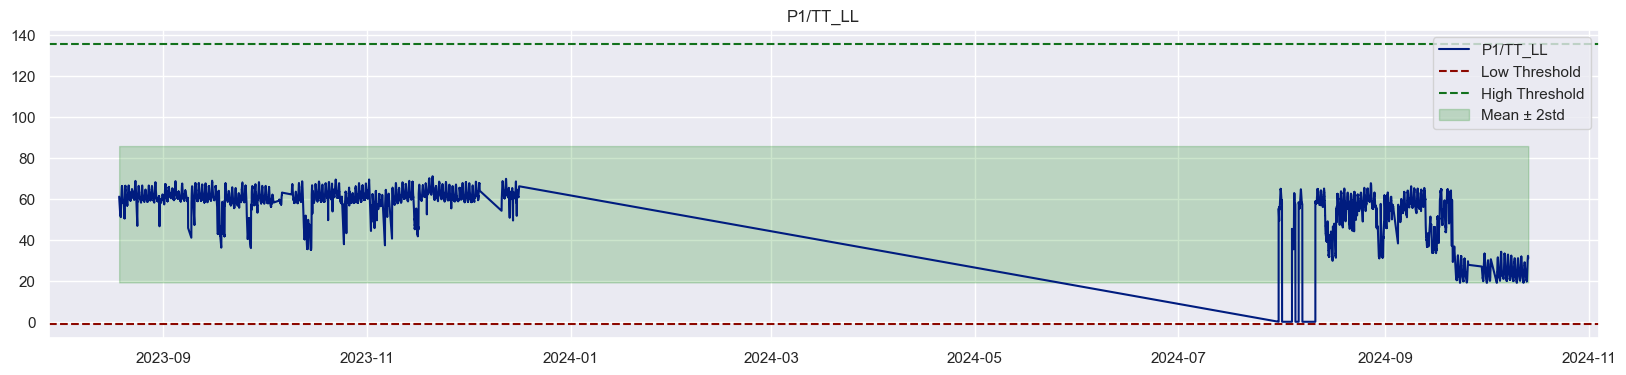

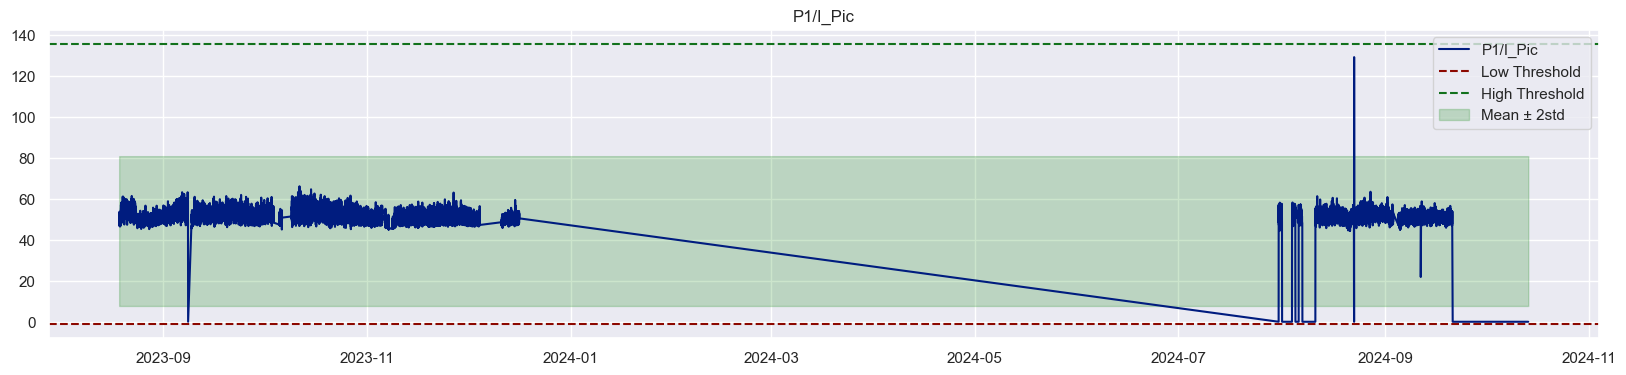

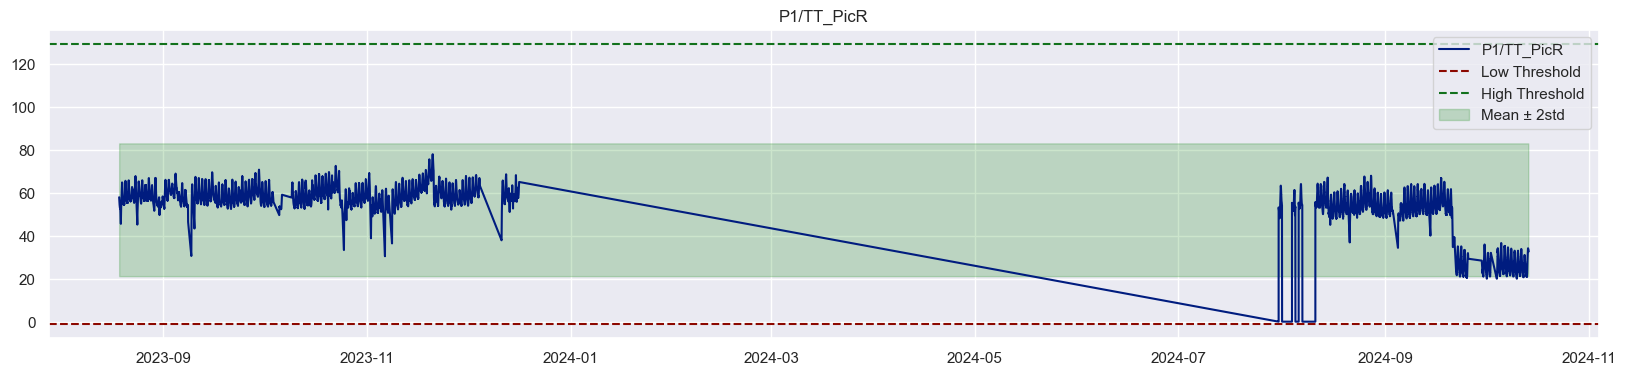

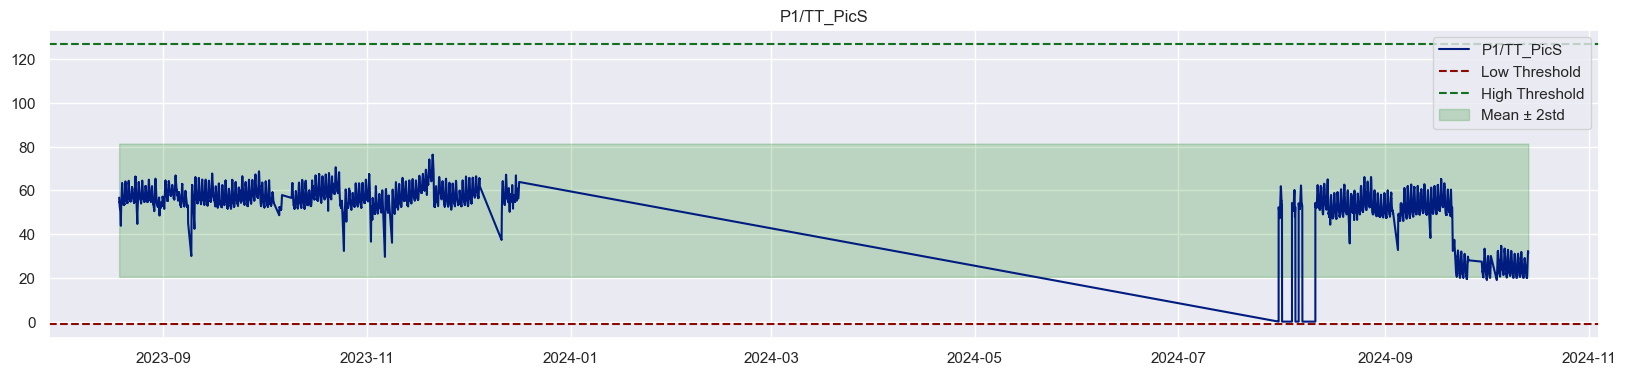

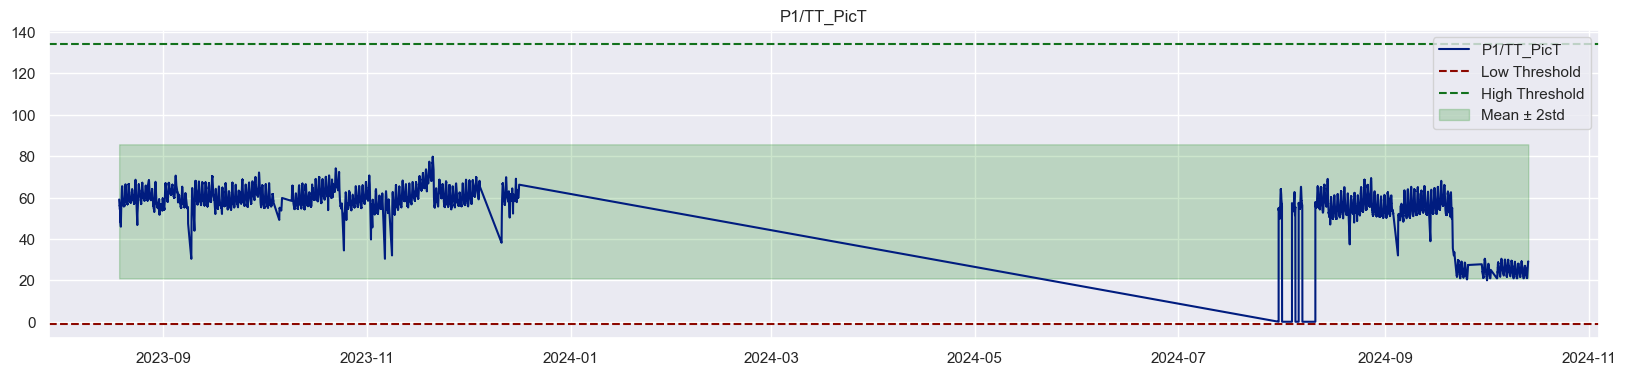

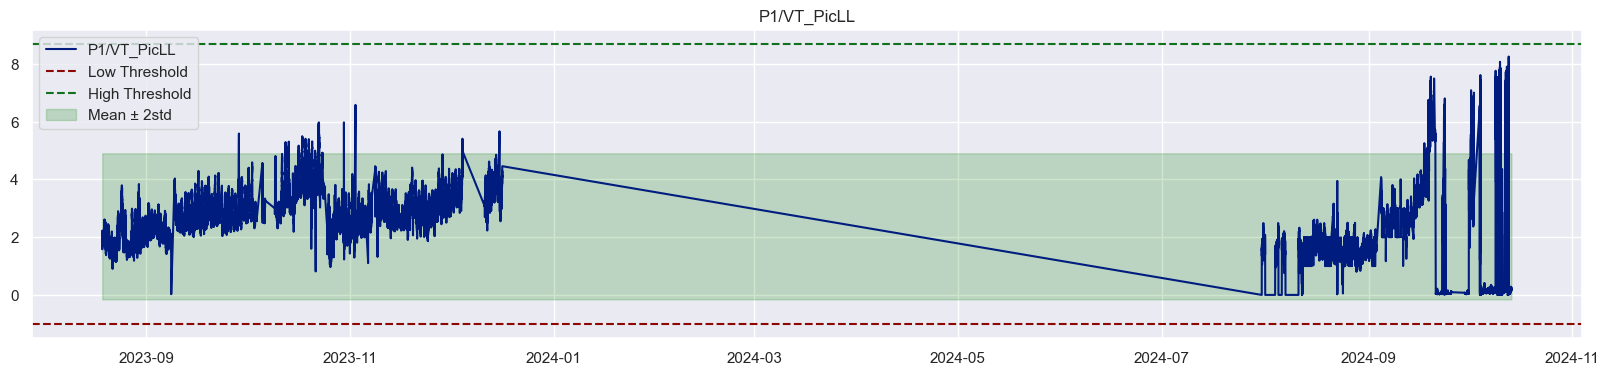

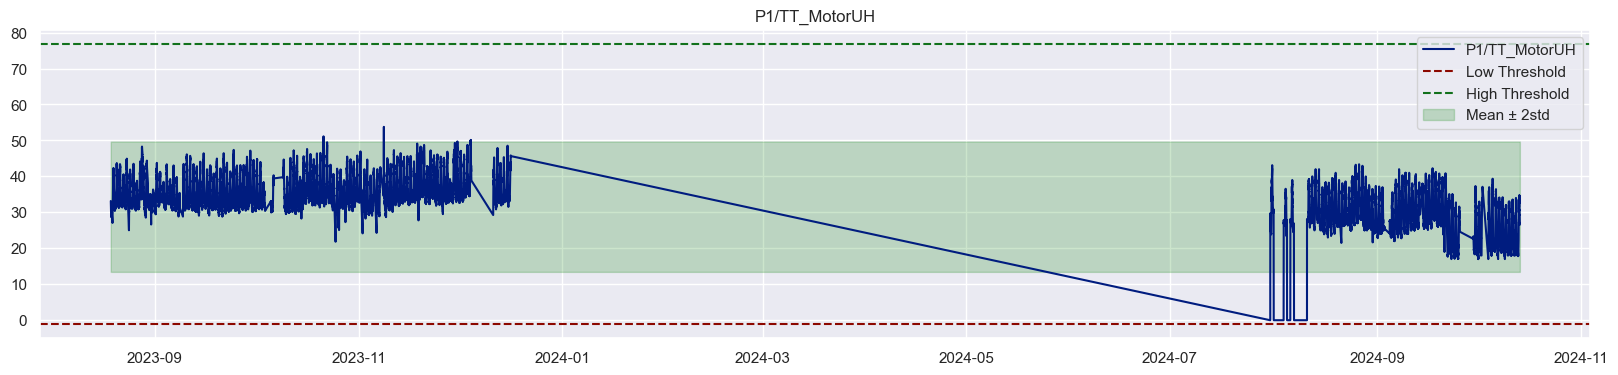

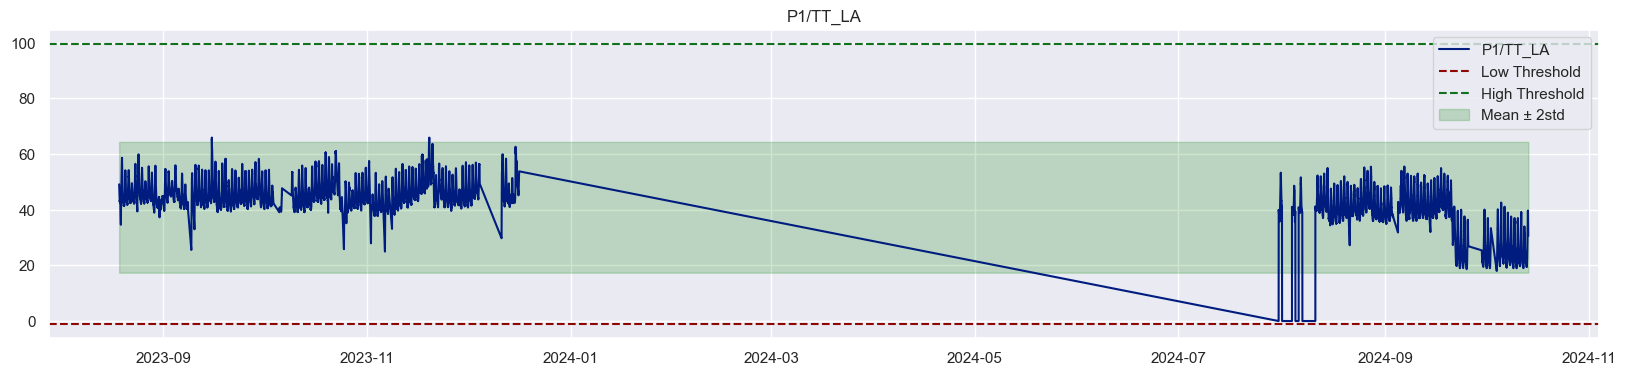

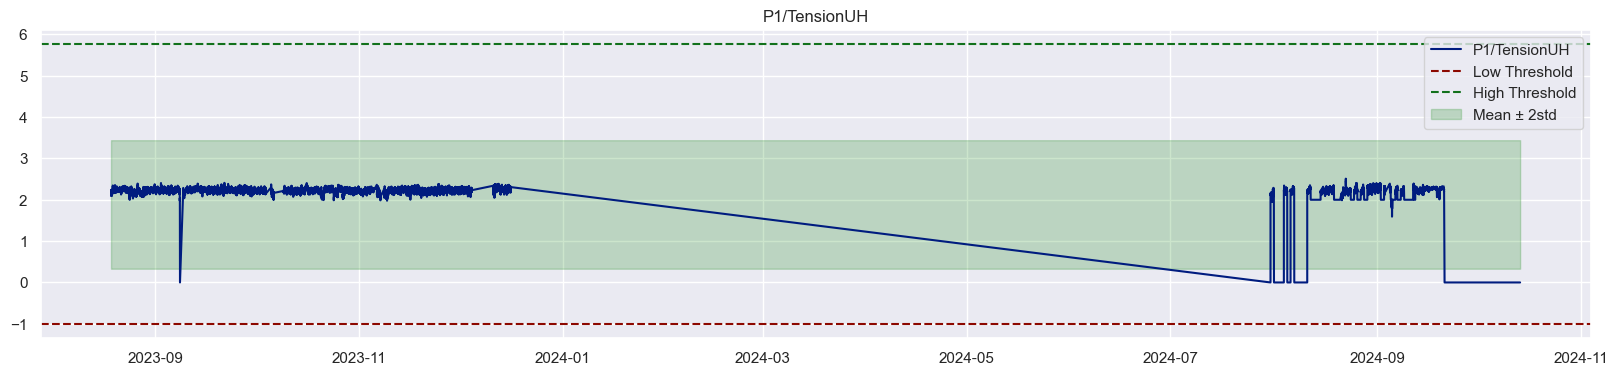

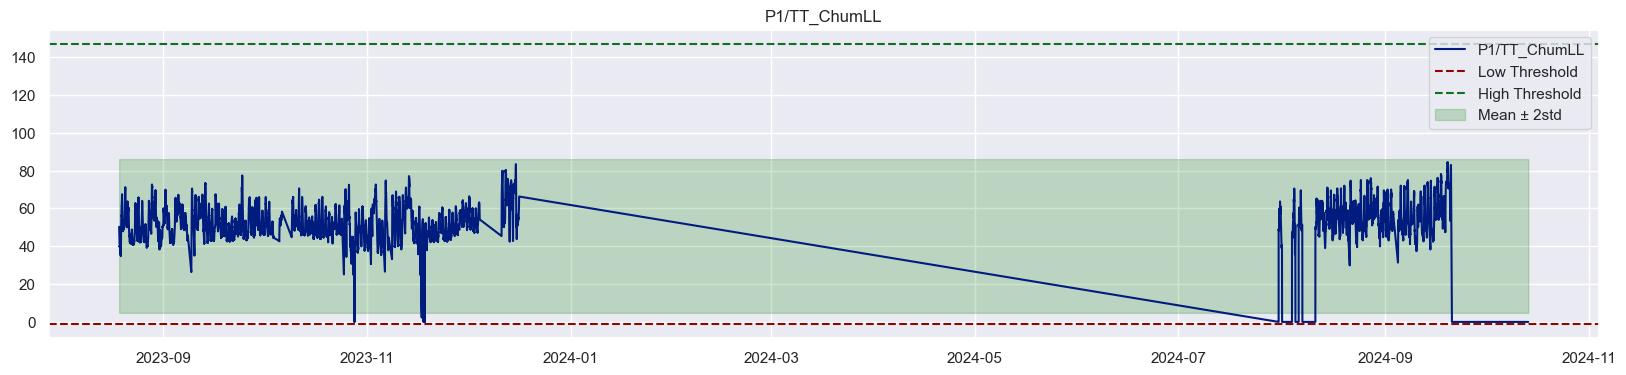

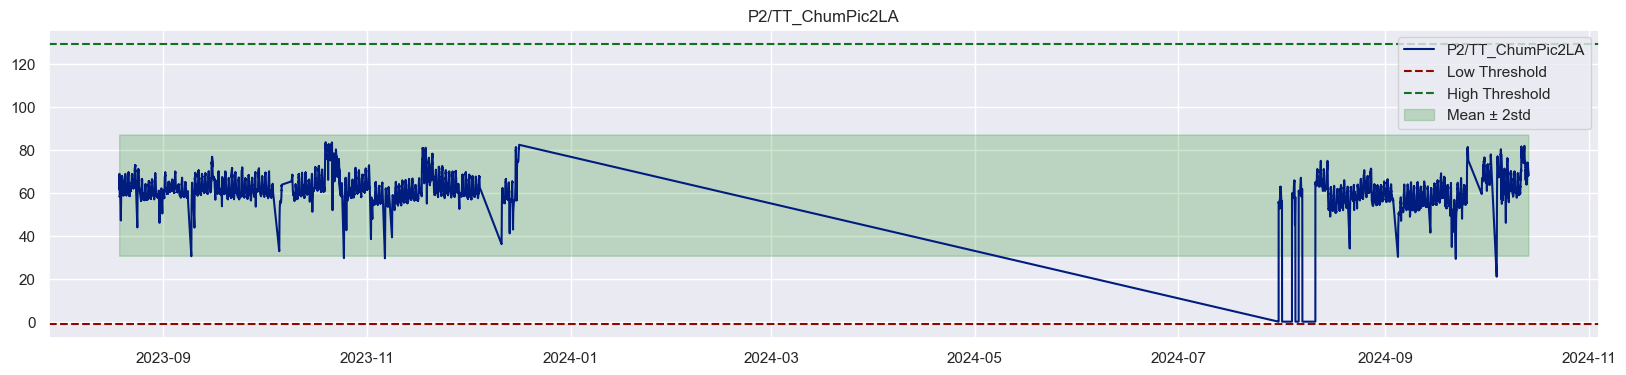

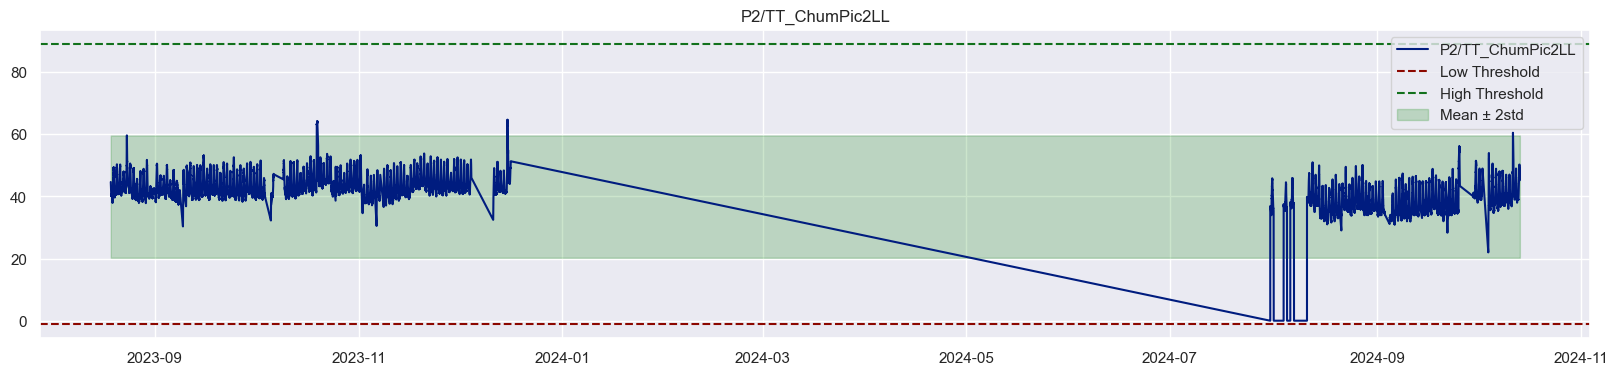

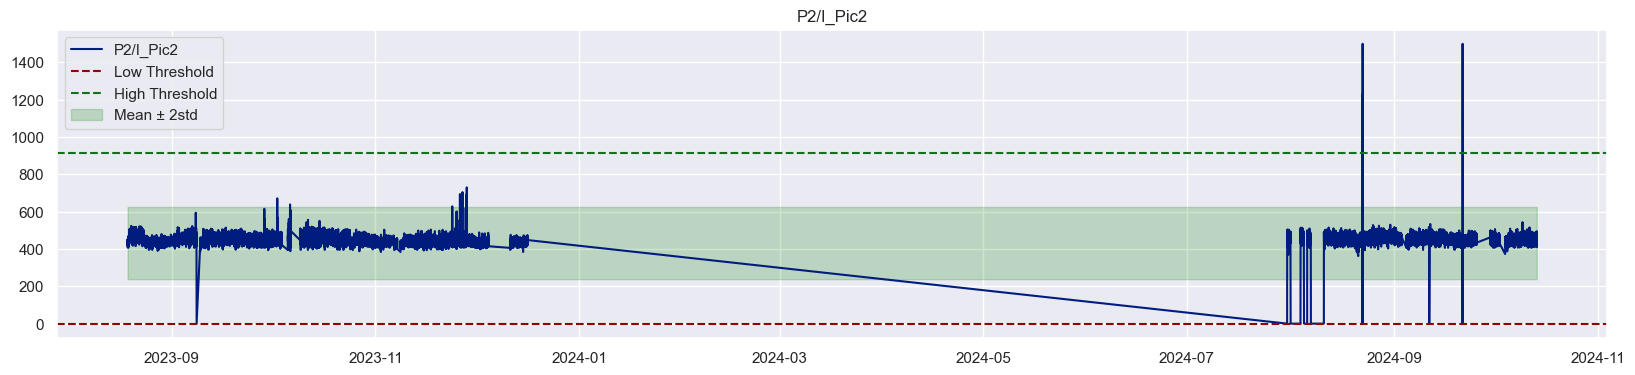

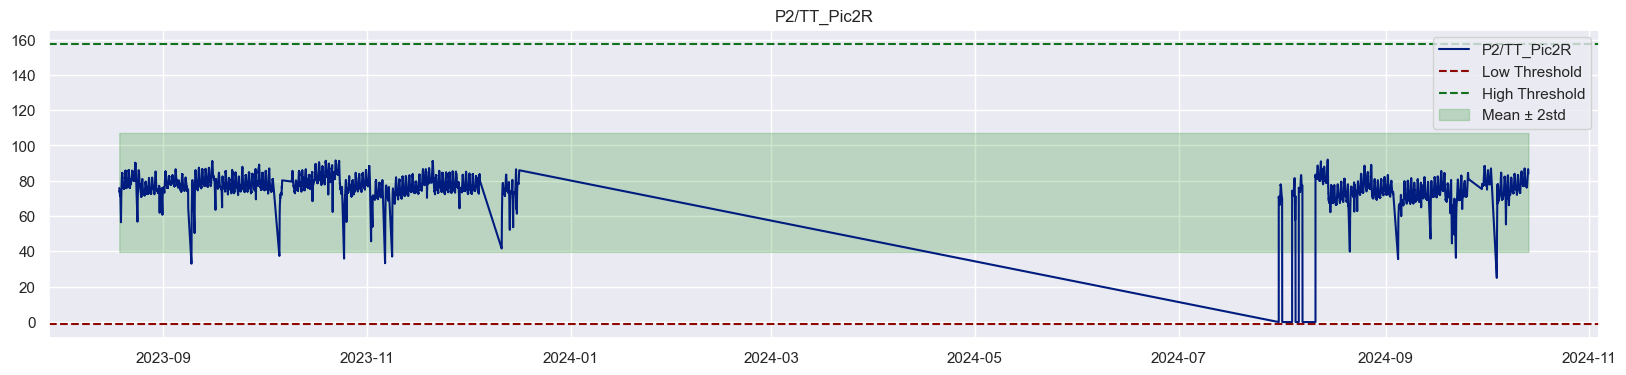

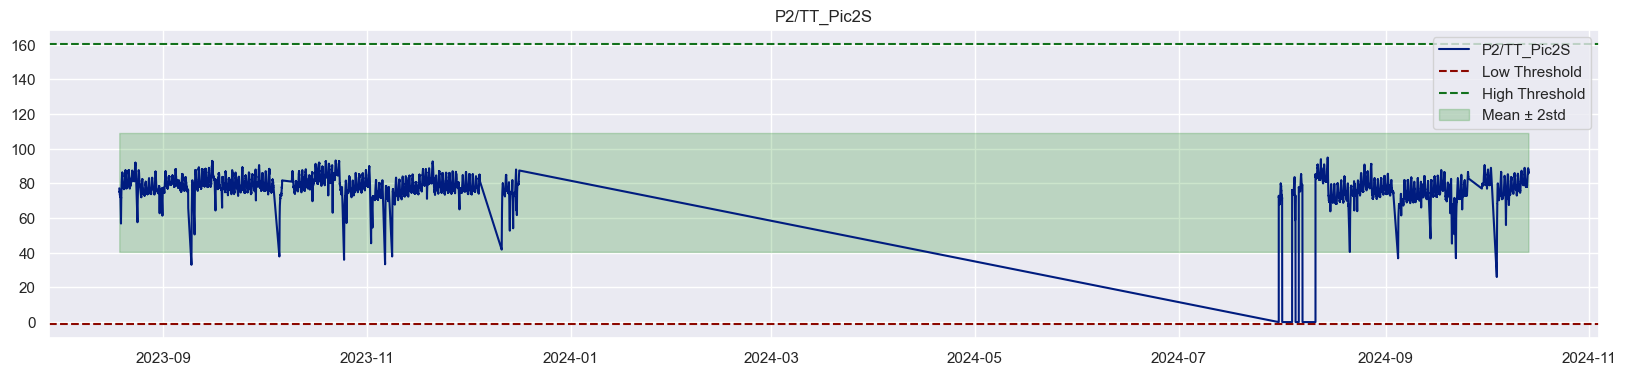

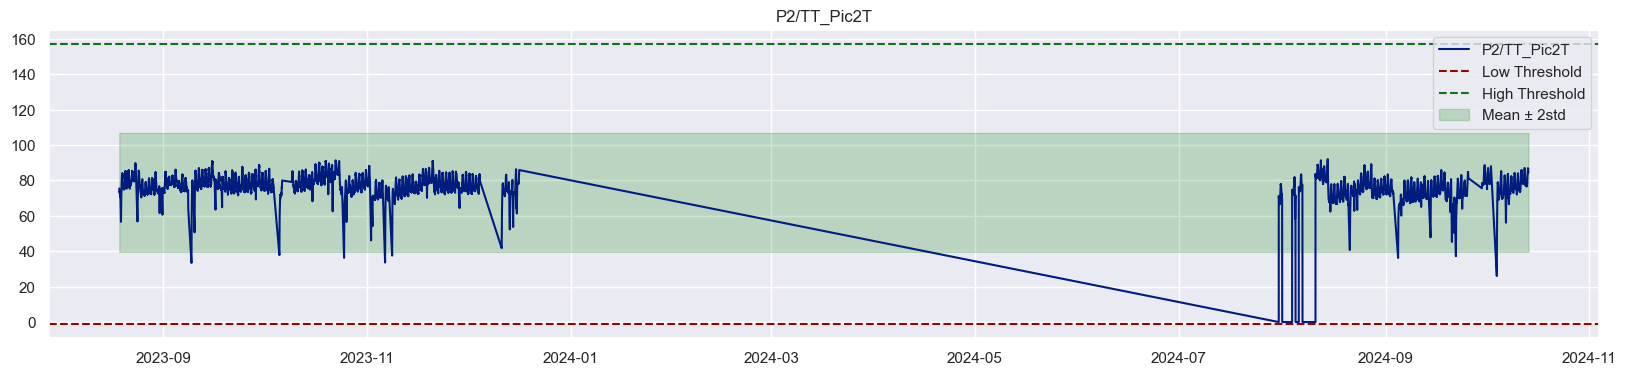

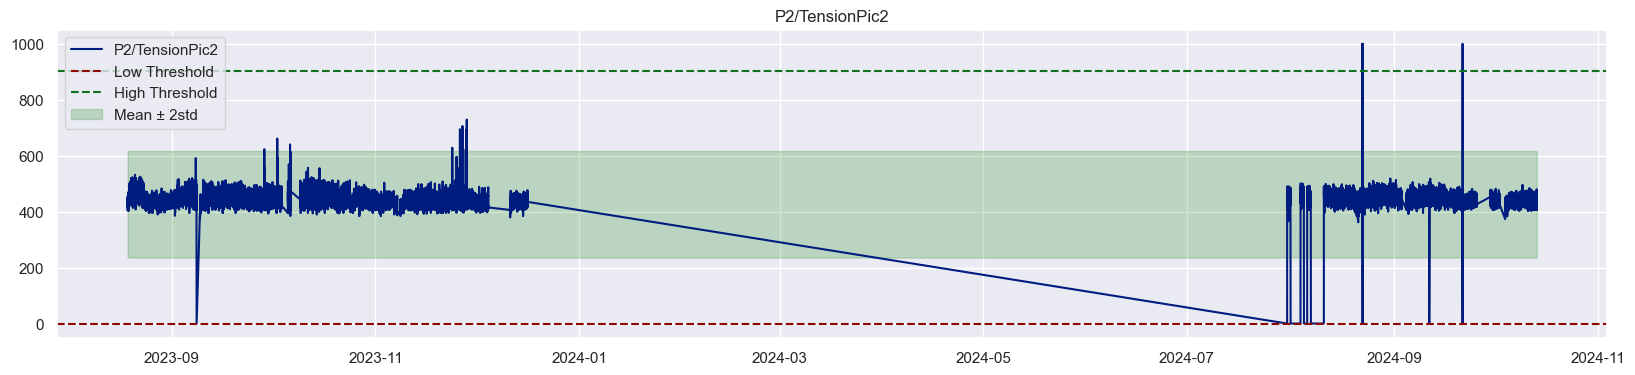

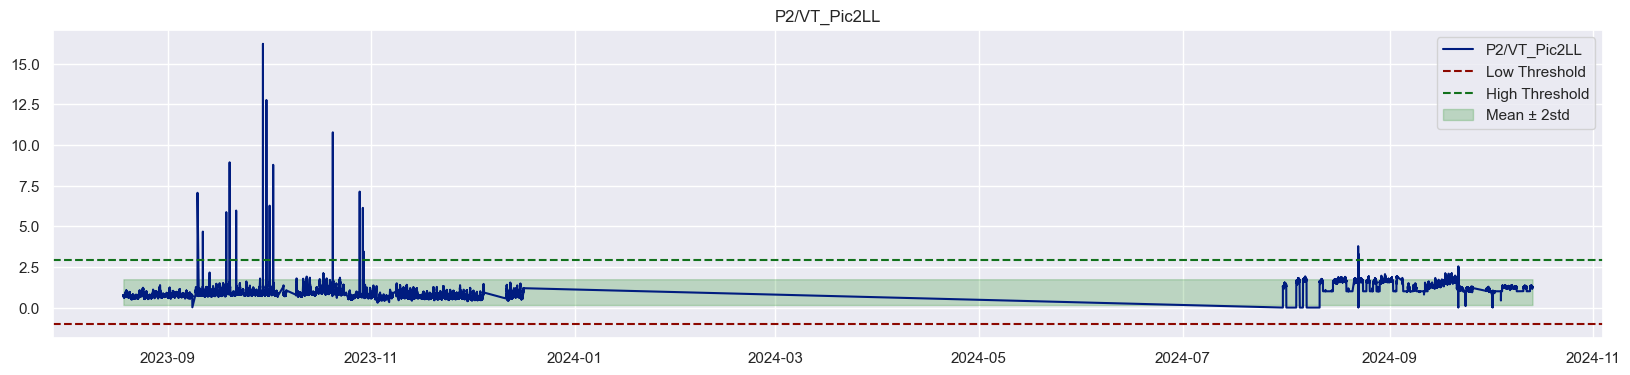

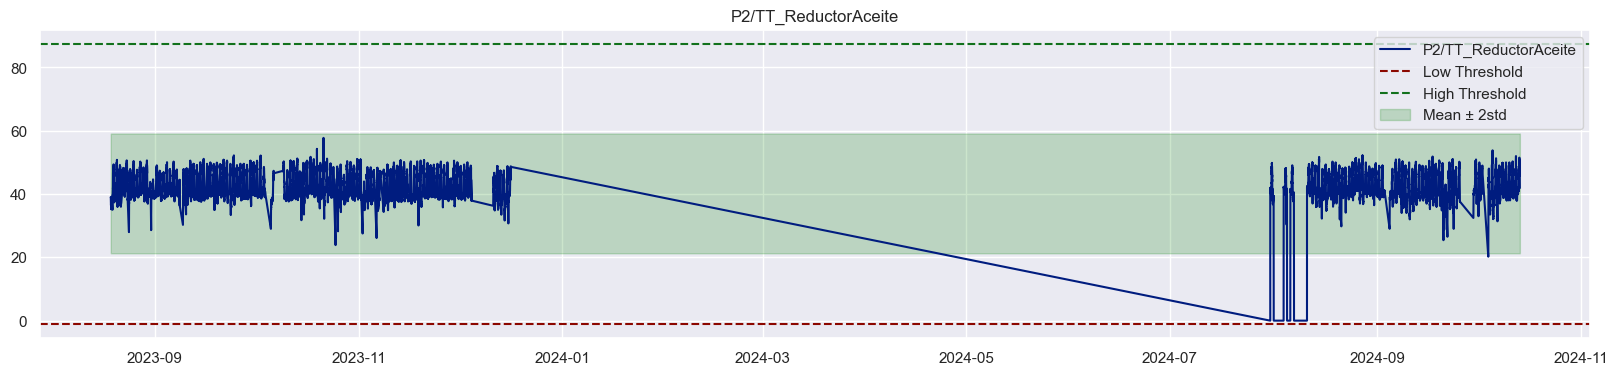

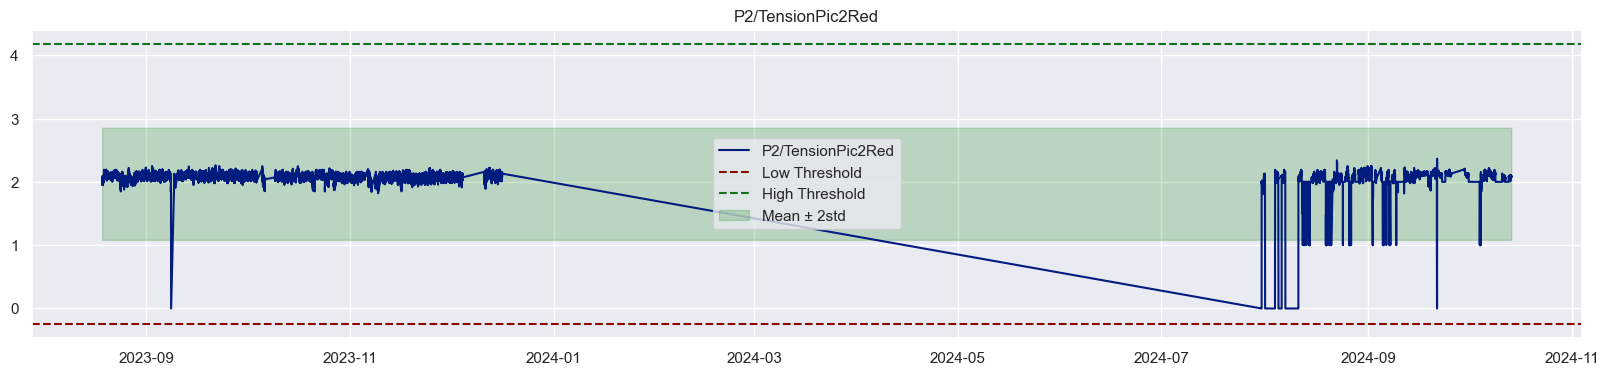

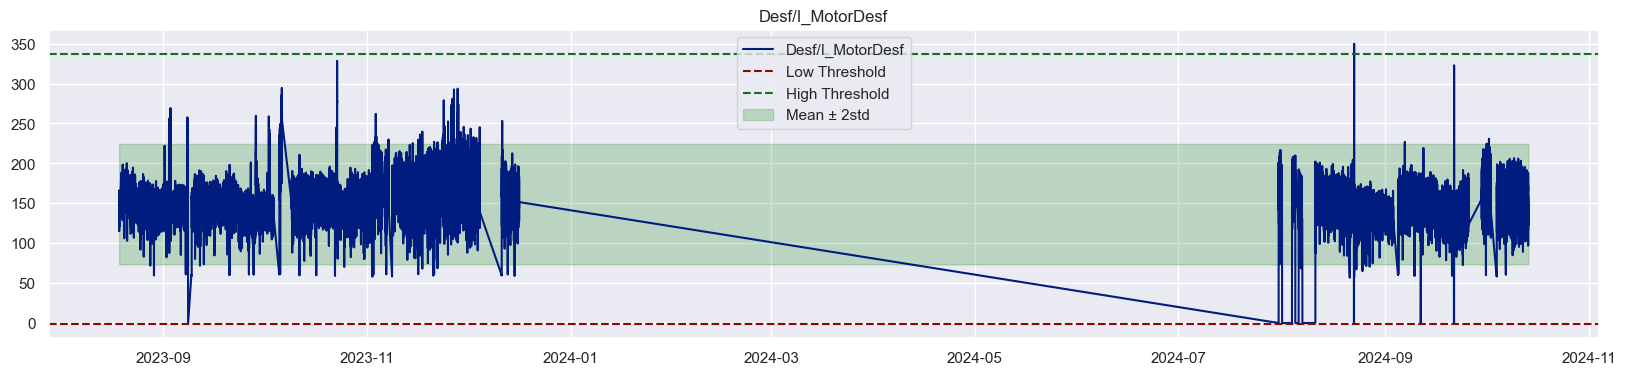

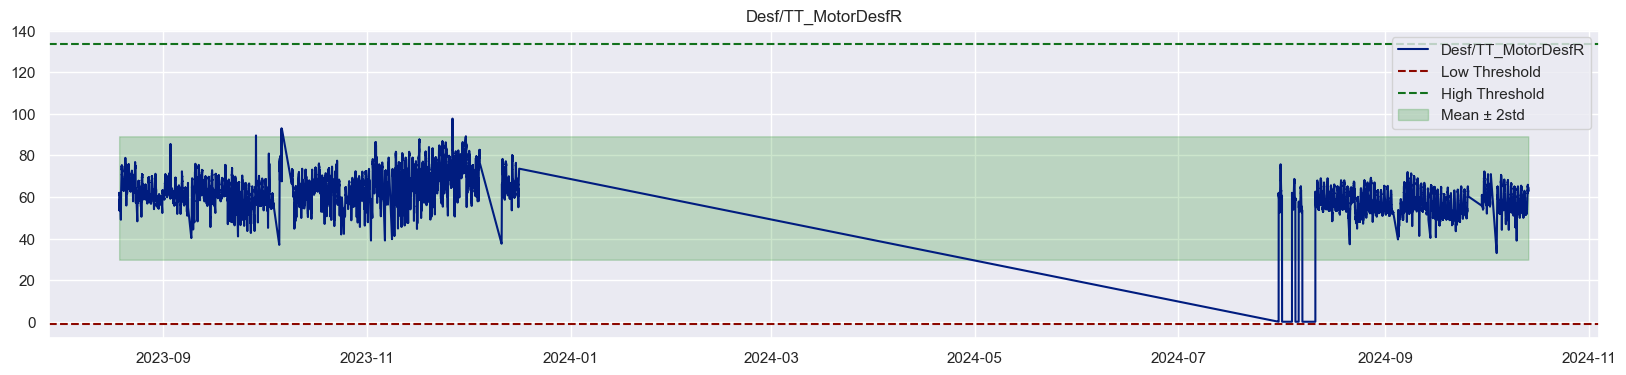

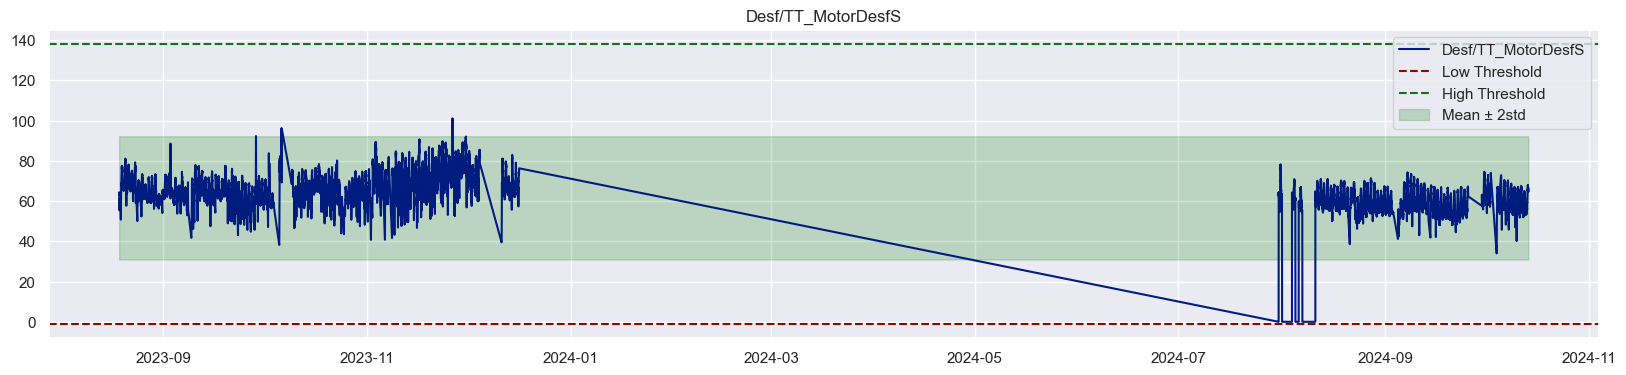

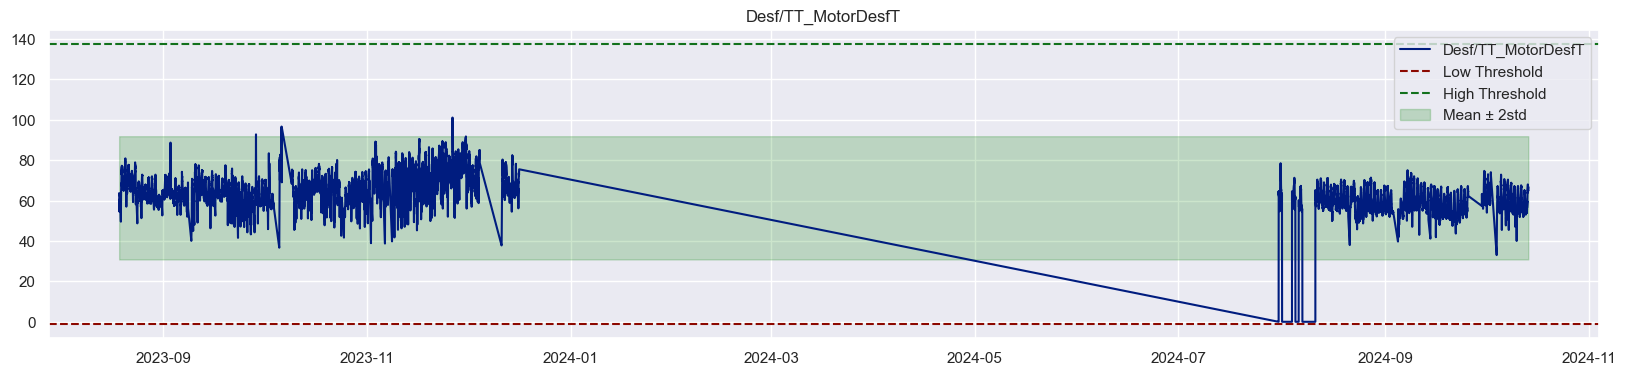

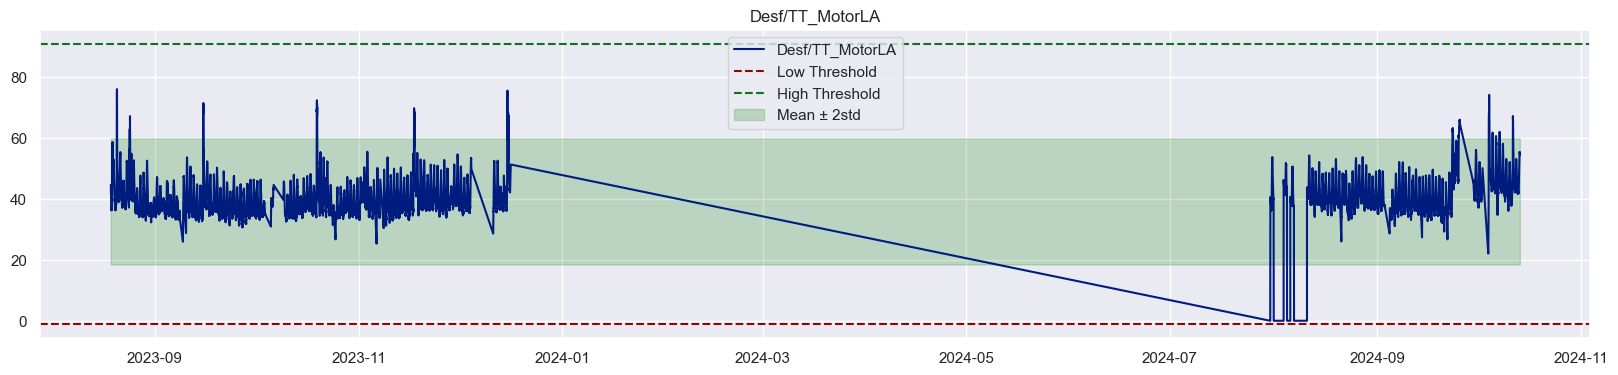

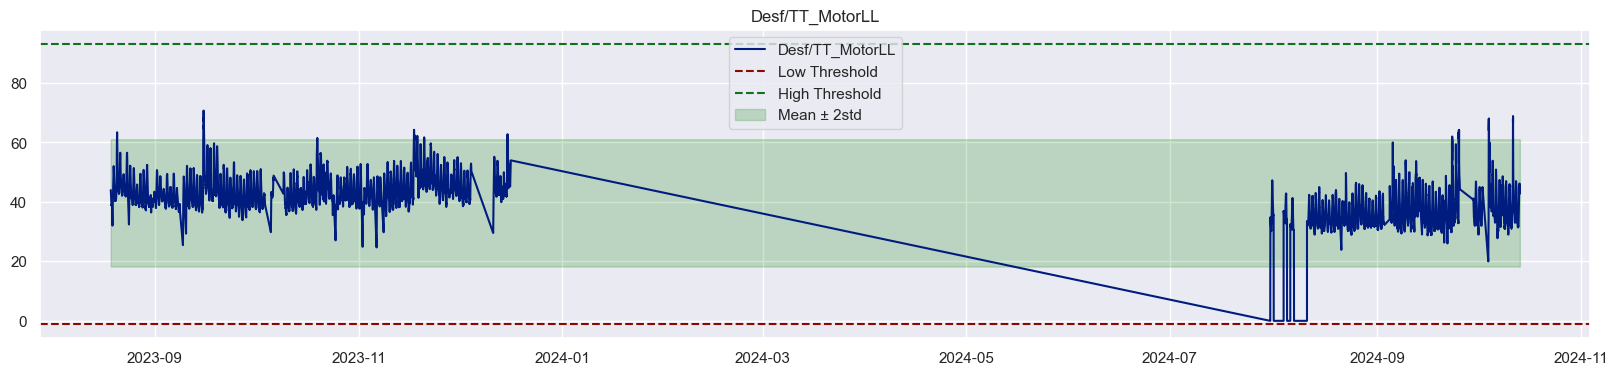

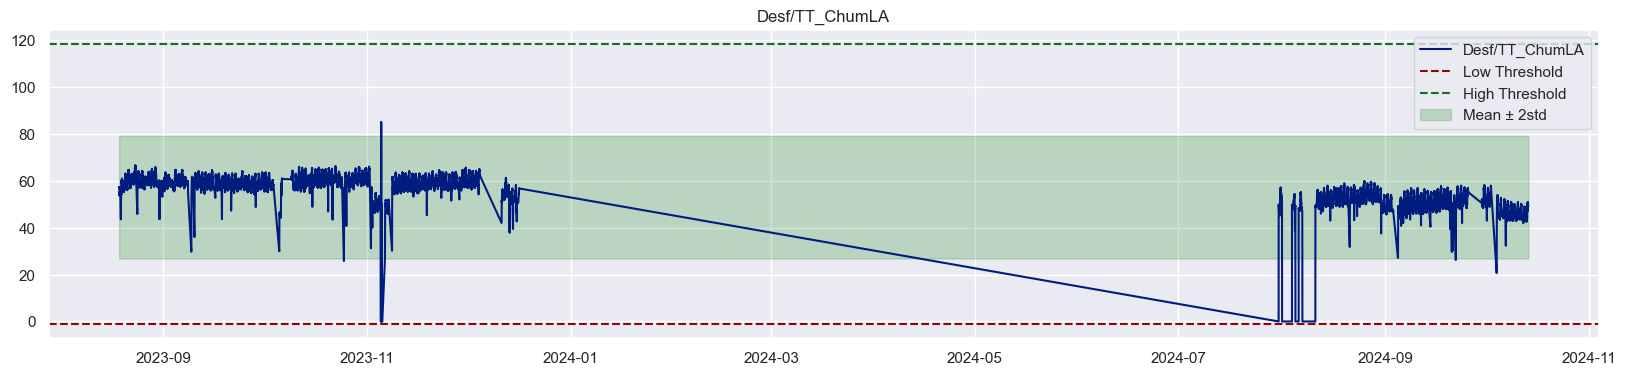

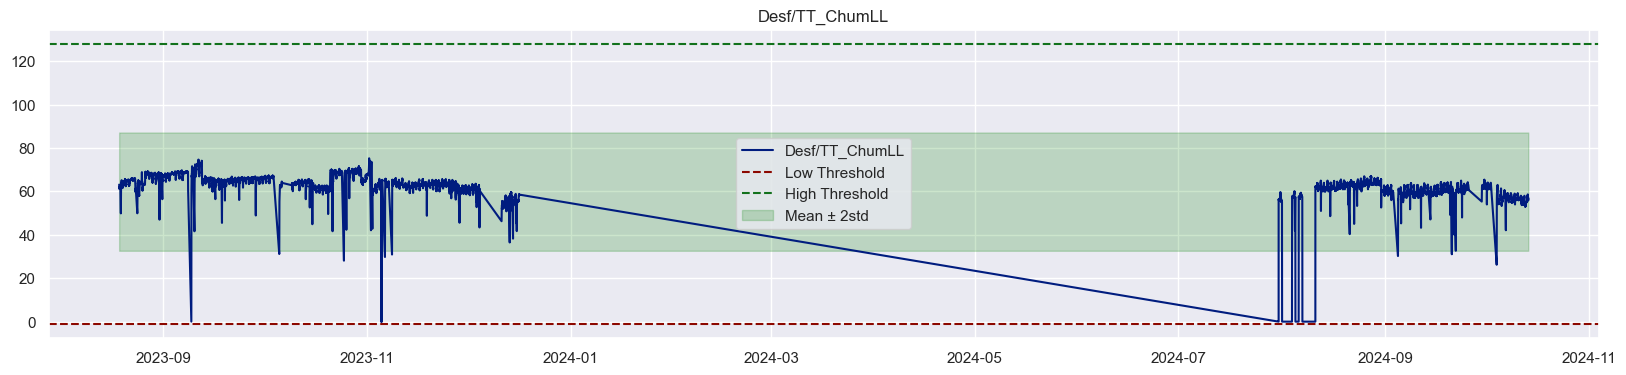

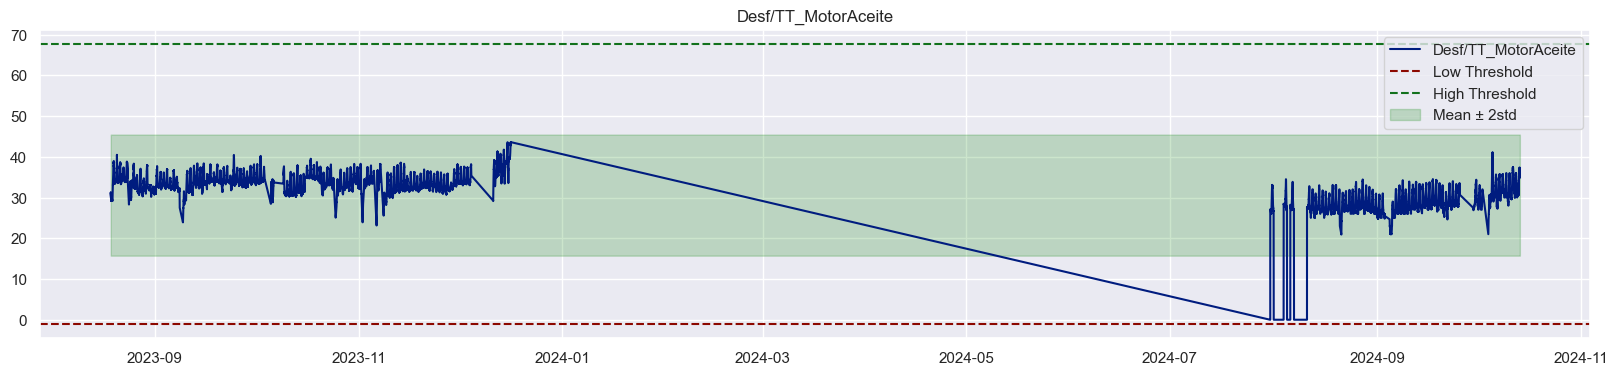

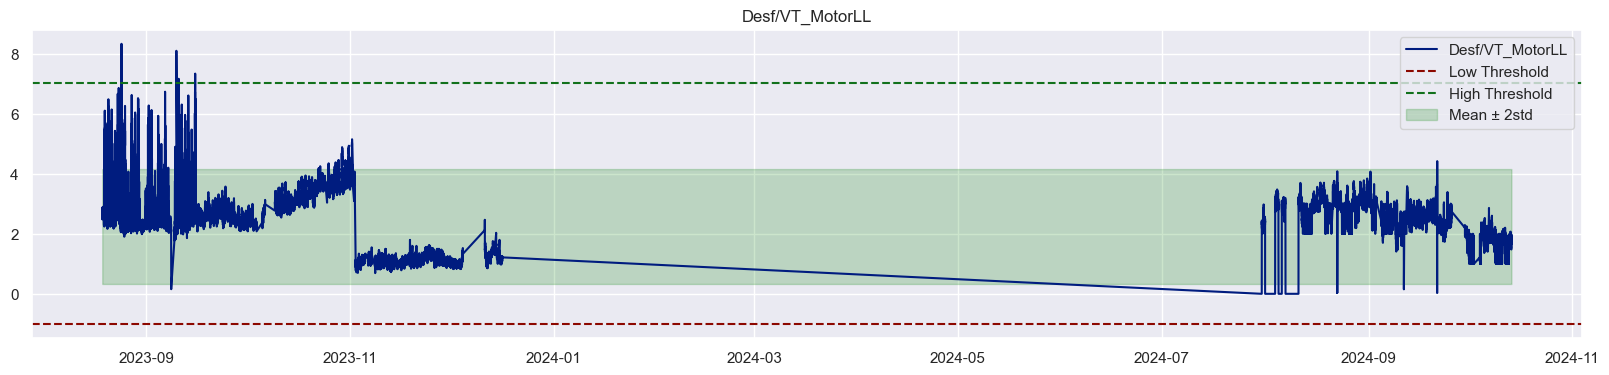

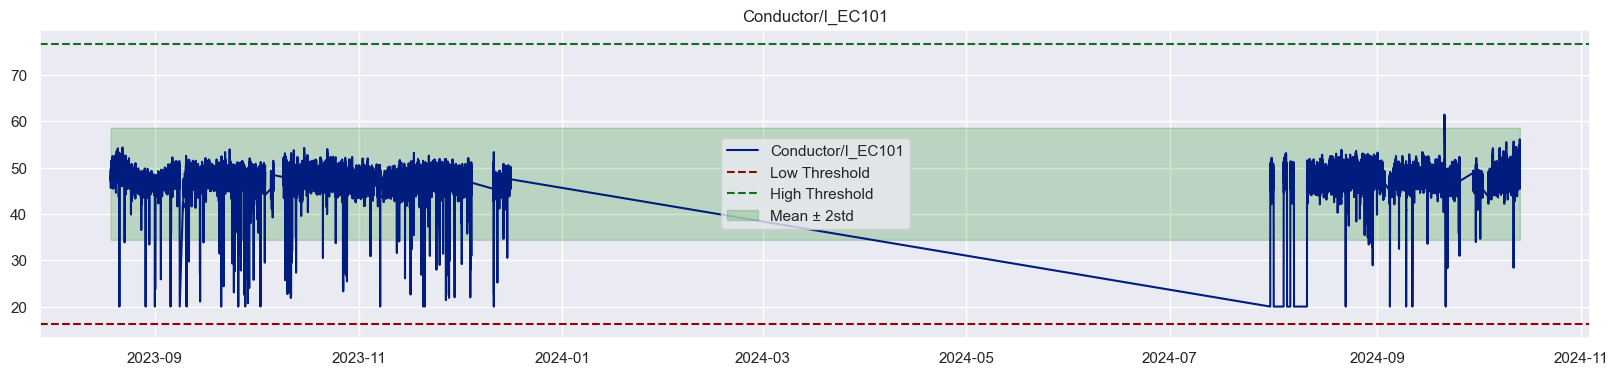

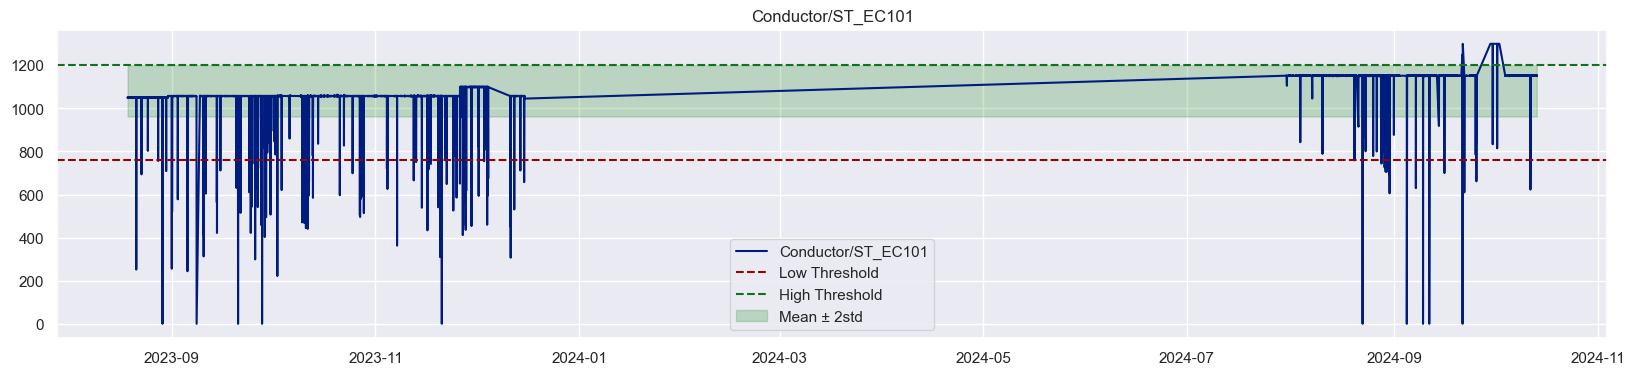

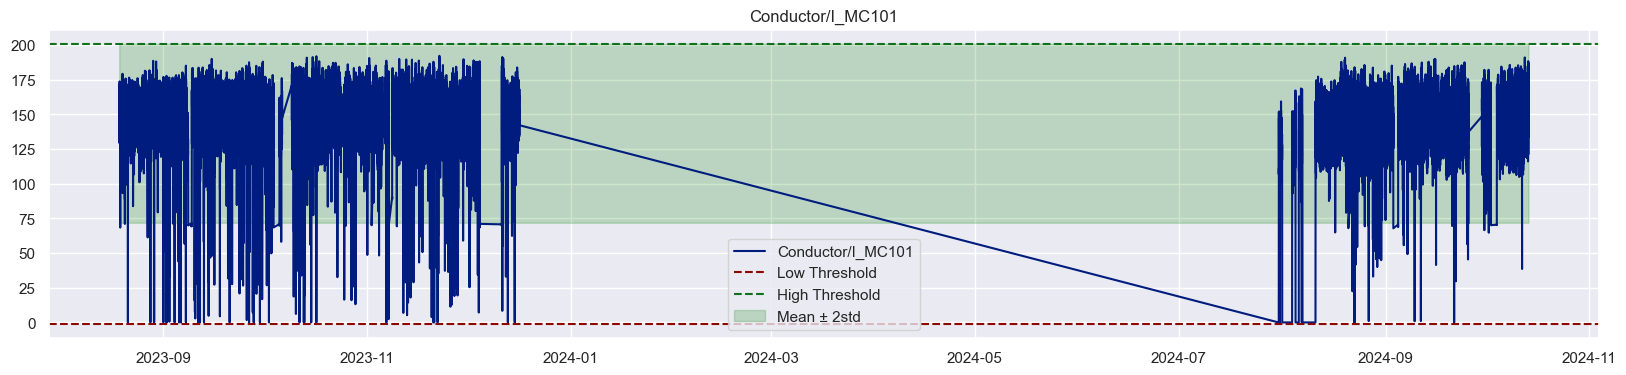

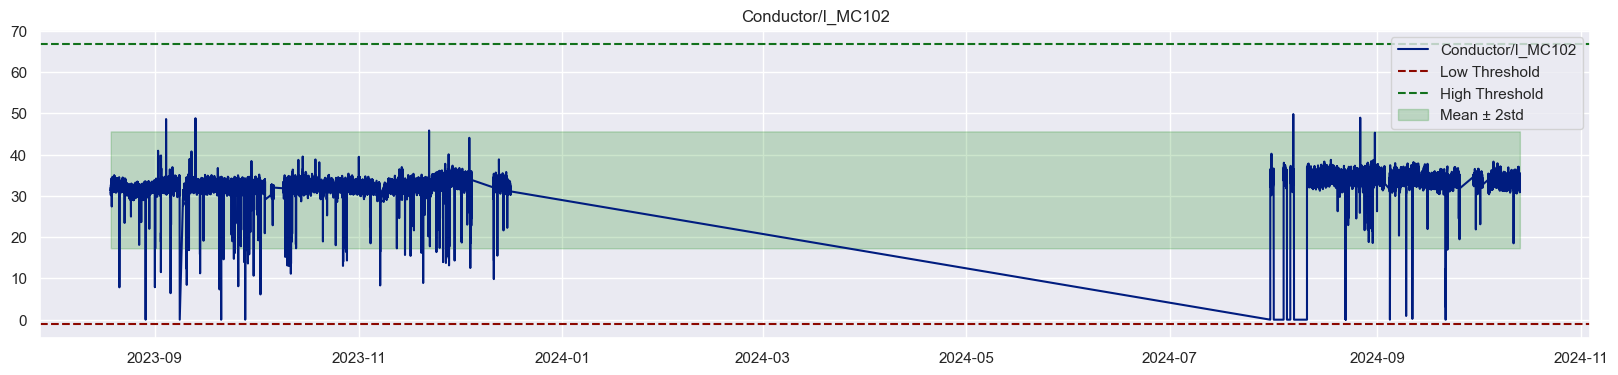

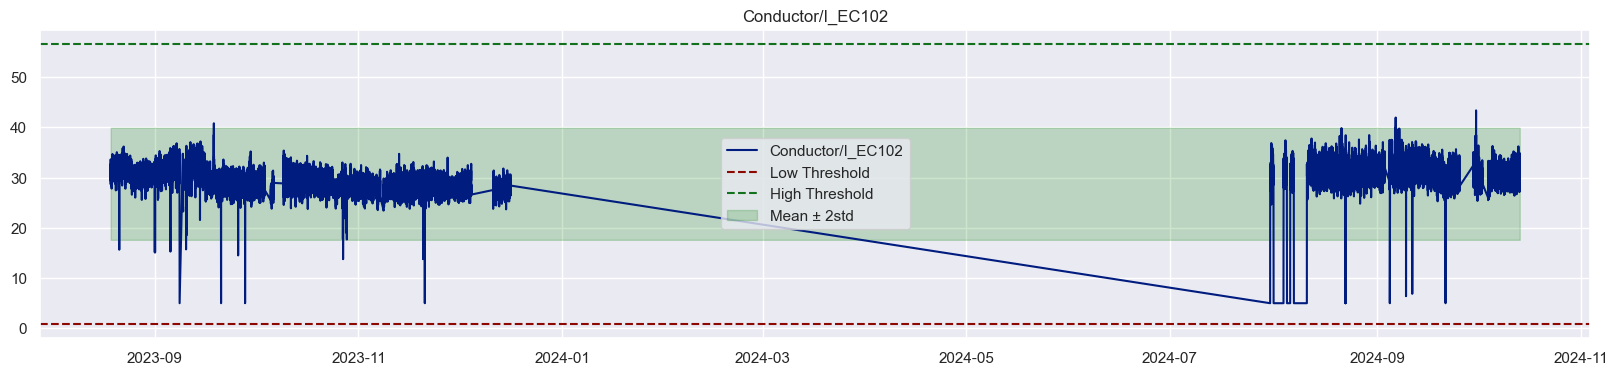

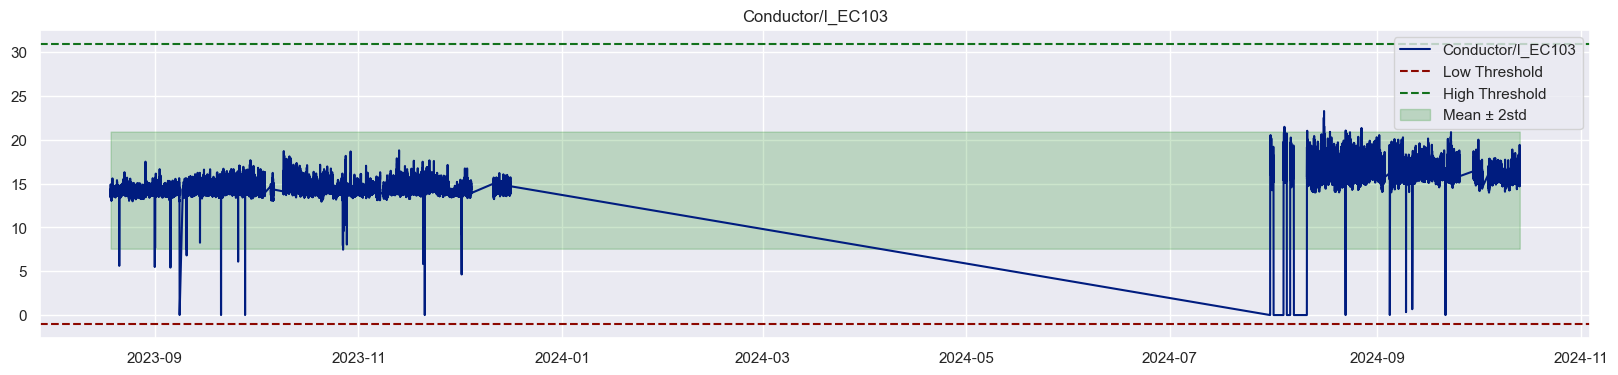

In [22]:
df_temp = df.copy() 

for item in df.columns:
    plt.figure(figsize=(20, 4))
    plt.plot(df_temp[item], label=item)
    
    # Obtener los umbrales para la variable actual
    low_threshold = df_umbrales.loc['low', item]
    high_threshold = df_umbrales.loc['high', item]
    mean = df_umbrales.loc['mean', item]
    
    # Agregar líneas horizontales para los umbrales
    plt.axhline(y=low_threshold, color='r', linestyle='--', label='Low Threshold')
    plt.axhline(y=high_threshold, color='g', linestyle='--', label='High Threshold')
    #Agregar 'mean_plus_std' y 'mean_minus_std' como una banda sombreada entre mean_plus_2std y mean_minus_2std
    plt.fill_between(df_temp.index, df_umbrales.loc['mean_minus_std', item], df_umbrales.loc['mean_plus_std', item], color='green', alpha=0.2, label='Mean ± 2std')
    
    plt.title(item)
    plt.legend()

    
    #Guardar las salidas en una carpeta de imagenes pero en el nomnbre de item no puede haber '/' por eso se reemplaza por '-'
    item = item.replace('/',' ')
    plt.savefig('images/'+item+'.png')
    plt.show()
    plt.close()
    

### CALCULO DE SCORE DE ANOMALIAS

In [23]:
def calculate_anomaly_score_1(df, df_umbrales, importancia=0.3):
    n = df_umbrales.loc['peso'].sum()   
    df_temp = df.copy()
    # Iterar sobre cada columna en df
    for column in df.columns:
        # Obtener los umbrales superior e inferior para la columna actual
        lower_bound = df_umbrales.loc['mean_minus_std', column]
        upper_bound = df_umbrales.loc['mean_plus_std', column]
    
        # Aplicar clip para limitar los valores de la columna actual
        df_temp[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
        df = df_temp.copy()
    anomaly_scores = pd.DataFrame(index=df.index)
    
    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_mean = df[column] > df_umbrales.loc['mean', column]
        # Si está por encima del promedio, usa mean_plus_std
        normalized_deviation_above = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df[column] - df_umbrales.loc['mean', column]) / (df_umbrales.loc['mean_plus_std', column] - df_umbrales.loc['mean', column]))
        ).where(above_mean, 0)  # Solo aplica cuando está por encima del promedio
        
        # Si está por debajo del promedio, usa mean_minus_std
        normalized_deviation_below = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df_umbrales.loc['mean', column] - df[column]) / (df_umbrales.loc['mean', column] - df_umbrales.loc['mean_minus_std', column]))
        ).where(~above_mean, 0)  # Solo aplica cuando está por debajo del promedio
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto 
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)/n
        
    return anomaly_scores



def calculate_anomaly_score_2(df, df_umbrales, importancia=0.7, b=10**(-8), a=5):
    n = df_umbrales.loc['peso'].sum()
    anomaly_scores = pd.DataFrame(index=df.index)

    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_2std = df[column] > df_umbrales.loc['mean_plus_std', column]
        below_2std = df[column] < df_umbrales.loc['mean_minus_std', column]
        
        # Si está por encima de 2std
        temp_above = (
            100*(abs((df[column] - df_umbrales.loc['mean_plus_std', column]) / (df_umbrales.loc['high', column] - df_umbrales.loc['mean_plus_std', column])))
        ).where(above_2std, 0) 
        #Si temp_above es mayor a 110, se le asigna 110
        temp_above = temp_above.where(temp_above<110,110)
        normalized_deviation_above = df_umbrales.loc['peso', column]*((n*b)*(temp_above**a)) 
        
        # Si está por debajo del promedio, usa mean_minus_2std
        temp_below=(
            100*(abs((df[column] - df_umbrales.loc['mean_minus_std', column]) / (df_umbrales.loc['low', column] - df_umbrales.loc['mean_minus_std', column])))
        ).where(below_2std, 0) 
        #If temp_below is greater than 110, it is assigned 110
        temp_below = temp_below.where(temp_below<110,110)
        
        normalized_deviation_below = df_umbrales.loc['peso', column]*((n*b)*(temp_below**a)) 
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto (puedes modificar esto para ponderar diferentes señales)
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)
    
    #dividir todo anomaly_scores por n con excepcón de la columna total_score
    anomaly_scores = anomaly_scores.div(30)
    

    #Multiplicar por importancia a todas las columnas excepto la columna total_score
    anomaly_scores = anomaly_scores.mul(importancia)
    anomaly_scores['total_score'] = anomaly_scores['total_score'].div(importancia)
    
    return anomaly_scores


In [24]:
anomaly_scores_1 = calculate_anomaly_score_1(df, df_umbrales, importancia=0.3)
anomaly_scores_2 = calculate_anomaly_score_2(df, df_umbrales, importancia=1, b=10**(-4), a=3)
anomaly_scores = (anomaly_scores_1 + anomaly_scores_2) 

64112


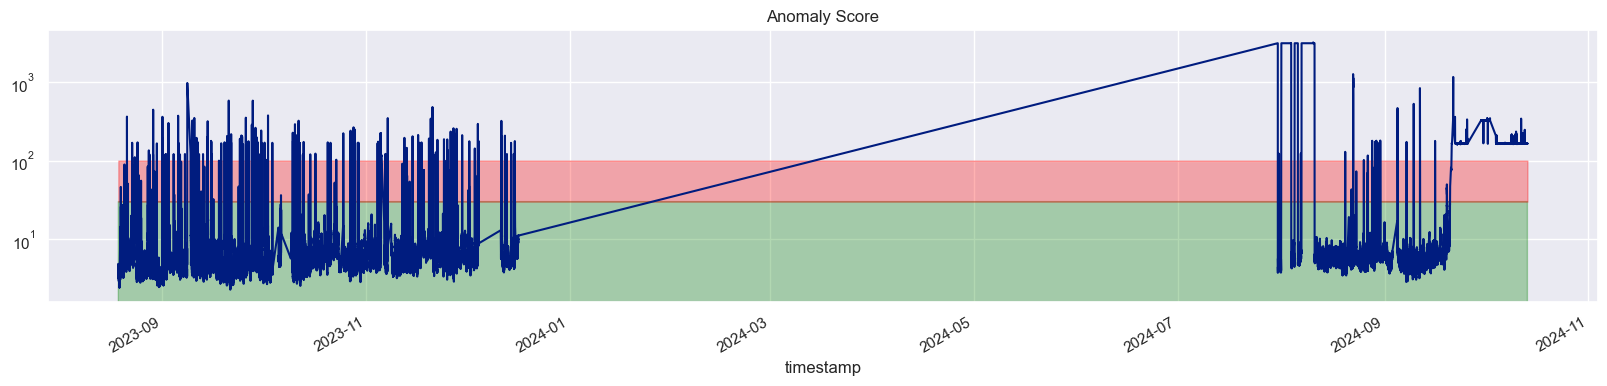

In [25]:
# Contar anomaly_scores mayores a 100
anomaly_count = anomaly_scores[anomaly_scores['total_score'] > 100].shape[0]
print(anomaly_count)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(20, 4))

# Graficar los datos
anomaly_scores = anomaly_scores #.iloc[-25000:-1].copy()
anomaly_scores['total_score'].plot(ax=ax, title='Anomaly Score') #.iloc[25000:25500]

# Cambiar la escala del eje y a logarítmica
ax.set_yscale('log')

#Agregar 'mean_plus_2std' y 'mean_minus_2std' como una banda sombreada entre mean_plus_2std y mean_minus_2std
plt.fill_between(anomaly_scores.index, 0, 30, color='green', alpha=0.3)
plt.fill_between(anomaly_scores.index, 30, 100, color='red', alpha=0.3)

# Mostrar el g
plt.show()

In [26]:
#Cuantas filas  en anomaly_scores tiene a total_score mayor a 100
100*(anomaly_scores[anomaly_scores['total_score'] > 100].shape[0])/(anomaly_scores.shape[0])

14.842424256455015

### MODELO DE DEEP LEARNING

In [28]:
# normalize the data
scaler = preprocessing.MinMaxScaler()
X_train = scaler.fit_transform(df_train)
X_test = scaler.transform(df_test)

# reshape inputs for LSTM [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
print("Training data shape:", X_train.shape)
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
print("Test data shape:", X_test.shape)

Training data shape: (431907, 1, 36)
Test data shape: (44, 1, 36)


In [29]:
# define the autoencoder network model
def autoencoder_model(X):
    inputs = Input(shape=(X.shape[1], X.shape[2]))
    L1 = LSTM(22, activation='relu', return_sequences=True, 
              kernel_regularizer=regularizers.l2(0.00))(inputs)
    L2 = LSTM(6, activation='relu', return_sequences=False)(L1)
    L3 = RepeatVector(X.shape[1])(L2)
    L4 = LSTM(6, activation='relu', return_sequences=True)(L3)
    L5 = LSTM(22, activation='relu', return_sequences=True)(L4)
    output = TimeDistributed(Dense(X.shape[2]))(L5)    
    model = Model(inputs=inputs, outputs=output)
    return model

# create the autoencoder model
model = autoencoder_model(X_train)
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 36)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 22)          │         5,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6)              │           696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 6)           │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 22)          │         2,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 36)          │           828 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,580 (37.42 KB)

 Trainable params: 9,580 (37.42 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Configurar EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=400, restore_best_weights=True)

# Ajustar el modelo a los datos
nb_epochs = 200
batch_size = 500

history = model.fit(X_train, X_train, epochs=nb_epochs, batch_size=batch_size,
                    validation_split=0.10, shuffle=True, callbacks=[early_stop]).history

Epoch 1/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.2421 - val_loss: 0.1799
Epoch 2/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0340 - val_loss: 0.1590
Epoch 3/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0302 - val_loss: 0.1575
Epoch 4/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0300 - val_loss: 0.1586
Epoch 5/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0297 - val_loss: 0.1596
Epoch 6/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0294 - val_loss: 0.1624
Epoch 7/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0292 - val_loss: 0.1656
Epoch 8/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0291 - val_loss: 0.1642
Epoch 9/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0282 - val_loss: 0.1645
Epoch 10/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0265 - val_loss: 0.1594
Epoch 11/200
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0255 - val_loss: 0.1569
Epoch 12/200
778/778 ━━━━━━━━━━━━━━━━━━━

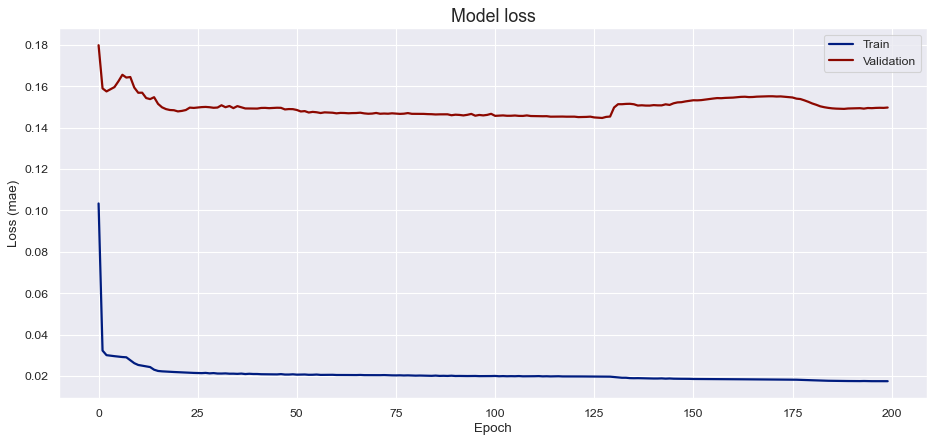

In [31]:
# plot the training losses
fig, ax = plt.subplots(figsize=(14, 6), dpi=80)
ax.plot(history['loss'], 'b', label='Train', linewidth=2)
ax.plot(history['val_loss'], 'r', label='Validation', linewidth=2)
ax.set_title('Model loss', fontsize=16)
ax.set_ylabel('Loss (mae)')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right')
plt.show()

13498/13498 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step


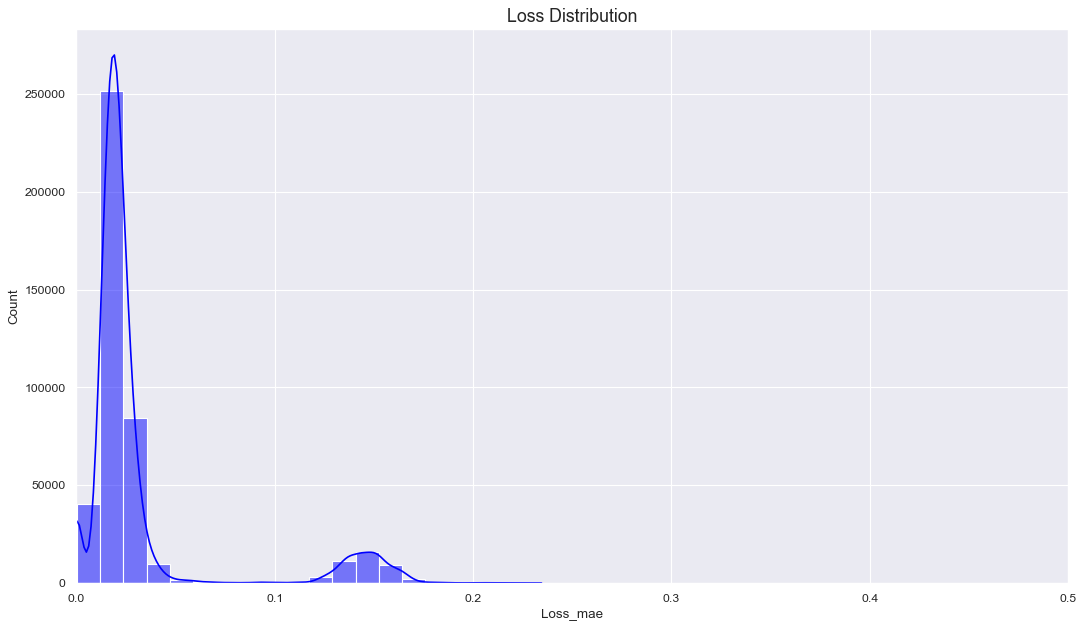

In [32]:
# Predecir con el modelo
X_pred = model.predict(X_train)
X_pred = X_pred.reshape(X_pred.shape[0], X_pred.shape[2])
X_pred = pd.DataFrame(X_pred, columns=df_train.columns)
X_pred_original = scaler.inverse_transform(X_pred) #Se guarda la prediccion en otro DS
X_pred.index = df_train.index

# Calcular la pérdida MAE
scored_train = pd.DataFrame(index=df_train.index)
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[2])
scored_train['Loss_mae'] = np.mean(np.abs(X_pred - X_train_reshaped), axis=1)

# Configurar la figura de Matplotlib
plt.figure(figsize=(16, 9), dpi=80)
plt.title('Loss Distribution', fontsize=16)

# Crear el histograma de la distribución de pérdida
sns.histplot(scored_train['Loss_mae'], bins=20, kde=True, color='blue')
plt.xlim([0.0, 0.5])

# Mostrar el gráfico
plt.show()

### UMBRALES

In [33]:
# Calcular el threshold automáticamente
mean_loss = np.mean(scored_train['Loss_mae'])
std_loss = np.std(scored_train['Loss_mae'])
threshold = mean_loss + 10 * std_loss
print(f'Threshold automático: {threshold}')

Threshold automático: 0.4197862394224356


In [34]:
scored_train['Threshold'] = threshold
scored_train['Anomaly'] = scored_train['Loss_mae'] > scored_train['Threshold']
#Convertir scored['Anomaly'] a booleano
scored_train['Anomaly'] = scored_train['Anomaly'].astype(int)

### Se Testea la red neuronal

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


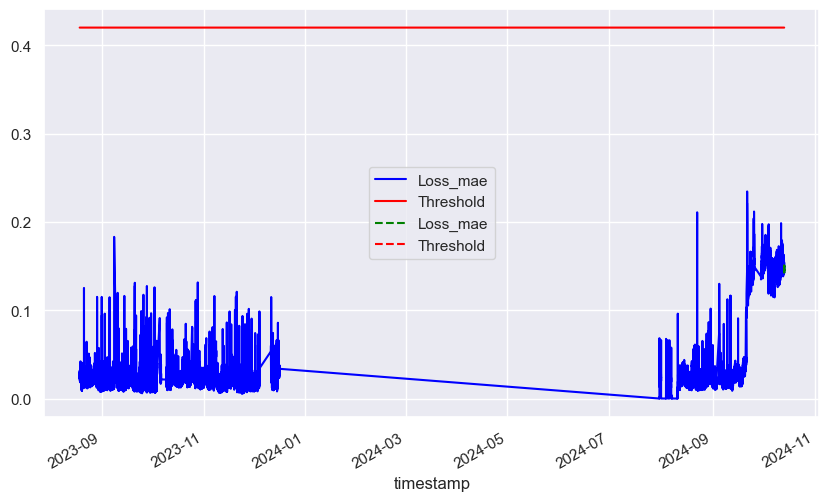

In [35]:
X_test_pred = model.predict(np.array(X_test))

X_test_pred = model.predict(X_test)
X_test_pred = X_test_pred .reshape(X_test_pred .shape[0], X_test_pred .shape[2])
X_test_pred = pd.DataFrame(X_test_pred , columns=df_test.columns)
X_test_pred.index = df_test.index
scored_test = pd.DataFrame(index=df_test.index)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[2])
scored_test['Loss_mae'] = np.mean(np.abs(X_test_pred - X_test_reshaped), axis=1)
scored_test['Threshold'] = threshold
scored_test['Anomaly'] = scored_test['Loss_mae'] > scored_test['Threshold']
#Convertir scored['Anomaly'] a booleano
scored_test['Anomaly'] = scored_test['Anomaly'].astype(int)

fig, ax = plt.subplots(figsize=(10,6))
scored_train[['Loss_mae', 'Threshold']].plot(logy=False, color=['blue','red'], ax=ax)
scored_test[['Loss_mae', 'Threshold']].plot(logy=False, color=['green','red'], ax=ax, linestyle='--')
plt.show()

In [36]:
#concatenar scored_train y scored_test
scored = pd.concat([scored_train, scored_test], axis=0) 
scored.columns=['Resultados.EC101.Factor de Anomalia EC101', 'Resultados.EC101.Umbral Anomalia EC101', 'Resultados.EC101.Anomalia EC101']

In [37]:
#En scored hacer 'Umbral Anomalia Molino' 100% y 'Factor de Anomalia Molino' sacar el porcentaje con respecto al umbral
scored['Resultados.EC101.Factor de Anomalia EC101'] = 100*scored['Resultados.EC101.Factor de Anomalia EC101'] / scored['Resultados.EC101.Umbral Anomalia EC101']
scored['Resultados.EC101.Factor de Anomalia EC101'] = scored['Resultados.EC101.Factor de Anomalia EC101'].clip(upper=110)
scored['Resultados.EC101.Umbral Anomalia EC101'] = 100
scored.head()


,Resultados.EC101.Factor de Anomalia EC101,Resultados.EC101.Umbral Anomalia EC101,Resultados.EC101.Anomalia EC101
timestamp,,,
2023-08-18 19:00:00-05:00,6.644584,100,0
2023-08-18 19:00:30-05:00,6.644584,100,0
2023-08-18 19:01:00-05:00,6.505354,100,0
2023-08-18 19:01:30-05:00,6.616406,100,0
2023-08-18 19:02:00-05:00,6.383847,100,0


<Axes: title={'center': 'Anomaly Score'}, xlabel='timestamp'>

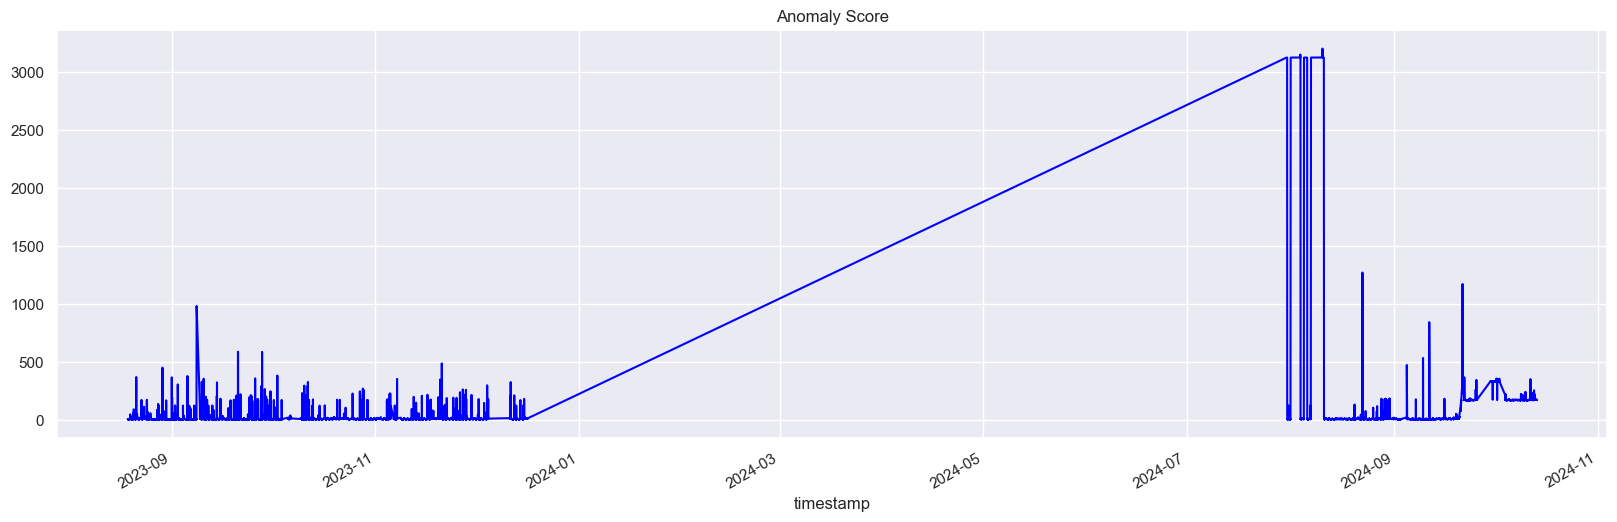

In [38]:
scored['Resultados.EC101.Factor de Anomalia EC101'] = 0.2*scored['Resultados.EC101.Factor de Anomalia EC101'] + anomaly_scores['total_score']
scored['Resultados.EC101.Factor de Anomalia EC101'].plot(figsize=(20, 6), color='blue', title='Anomaly Score')

In [39]:
#Contar cuantas filas son mayores a 100 en 'Factor de Anomalia Caldero'
len(scored[scored['Resultados.EC101.Factor de Anomalia EC101']>100]), len(scored)

(64116, 431951)

In [40]:
# Guardar el scaler en la carpeta models
dump(scaler, 'models/scaler8_EC101.pkl')
model.save('models/model8_EC101.keras')

#Guardar el threshold en dataframe de pandas con nombre de columna threshold en un csv
threshold = pd.DataFrame(data={'threshold': [threshold]})
threshold.to_csv('data/EC101/threshold_EC101.csv', index=False)

df_umbrales.to_csv('data/EC101/umbrales_EC101.csv', index=True)